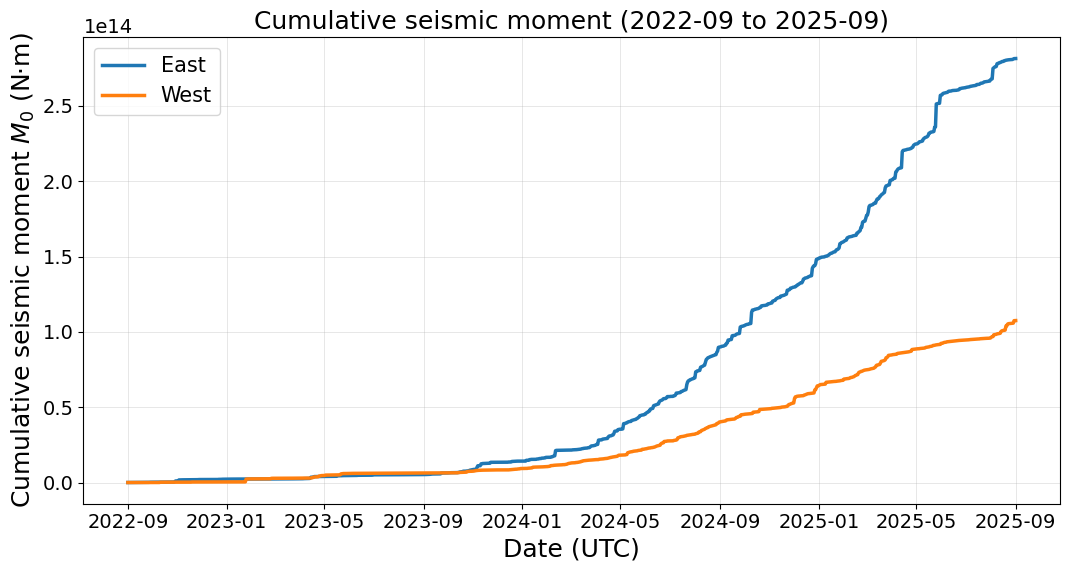

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from scipy.io import loadmat

# Load MAT
m = loadmat("../Data/ForMaleenV4.mat", squeeze_me=True, struct_as_record=False)
S = np.ravel(m["S"])

def matlab_datenum_to_datetime(dn_arr):
    dn = np.asarray(dn_arr, dtype=np.float64)
    days = np.floor(dn).astype(np.int64)
    frac = dn - days
    base_ord = np.array([dt.datetime.fromordinal(int(d)) for d in days], dtype=object)
    delta_frac = np.array([dt.timedelta(days=float(f)) for f in frac], dtype=object)
    out = base_ord + delta_frac - np.array([dt.timedelta(days=366)] * len(dn), dtype=object)
    return pd.to_datetime(out)

time_dn = np.array([getattr(x, "time", np.nan) for x in S], dtype=np.float64)
lat = np.array([getattr(x, "lat", np.nan) for x in S], dtype=np.float64)
lon = np.array([getattr(x, "lon", np.nan) for x in S], dtype=np.float64)
Mw = np.array([getattr(x, "Mw", np.nan) for x in S], dtype=np.float64)

time_dt = matlab_datenum_to_datetime(time_dn).tz_localize("UTC")

df = pd.DataFrame({"time_utc": time_dt, "lat": lat, "lon": lon, "Mw": Mw})
df["time_utc"] = pd.to_datetime(df["time_utc"], utc=True, errors="coerce")
df["lon_w"] = -df["lon"].astype(float)

# East and West polygons as boxes (°W)
w_latmin, w_latmax = 45.930, 45.950
w_lonmin, w_lonmax = -130.029, -130.008

e_latmin, e_latmax = 45.930, 45.970
e_lonmin, e_lonmax = -130.0015, -129.975

# Time window 2022-09 to 2025-09
TMIN = pd.Timestamp("2022-09-01", tz="UTC")
TMAX = pd.Timestamp("2025-09-01", tz="UTC")

df = df[df["time_utc"].notna() & df["Mw"].notna()].copy()
df = df[(df["time_utc"] >= TMIN) & (df["time_utc"] <= TMAX)]

west = df[
    np.isfinite(df["lon_w"].to_numpy())
    & np.isfinite(df["lat"].to_numpy())
    & (df["lon_w"] >= w_lonmin) & (df["lon_w"] <= w_lonmax)
    & (df["lat"] >= w_latmin) & (df["lat"] <= w_latmax)
].copy()

east = df[
    np.isfinite(df["lon_w"].to_numpy())
    & np.isfinite(df["lat"].to_numpy())
    & (df["lon_w"] >= e_lonmin) & (df["lon_w"] <= e_lonmax)
    & (df["lat"] >= e_latmin) & (df["lat"] <= e_latmax)
].copy()

# Moment conversion: log10(M0 [N·m]) = 1.5*Mw + 9.1
def mw_to_m0(mw):
    mw = np.asarray(mw, dtype=float)
    return 10 ** (1.5 * mw + 9.1)

west["M0_Nm"] = mw_to_m0(west["Mw"].to_numpy())
east["M0_Nm"] = mw_to_m0(east["Mw"].to_numpy())

# Daily summed moment and cumulative
all_days = pd.date_range(TMIN.floor("D"), TMAX.floor("D"), freq="D", tz="UTC")

west_daily_m0 = west.groupby(west["time_utc"].dt.floor("D"))["M0_Nm"].sum().reindex(all_days, fill_value=0.0)
east_daily_m0 = east.groupby(east["time_utc"].dt.floor("D"))["M0_Nm"].sum().reindex(all_days, fill_value=0.0)

west_cum_m0 = west_daily_m0.cumsum()
east_cum_m0 = east_daily_m0.cumsum()

# Plot (no explicit colors)
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 15,
})

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(all_days.to_pydatetime(), east_cum_m0.to_numpy(), label="East", linewidth=2.5)
ax.plot(all_days.to_pydatetime(), west_cum_m0.to_numpy(), label="West", linewidth=2.5)

ax.set_xlabel("Date (UTC)")
ax.set_ylabel("Cumulative seismic moment $M_0$ (N·m)")
ax.set_title("Cumulative seismic moment (2022-09 to 2025-09)")
ax.grid(True, linewidth=0.6, alpha=0.35)
ax.legend(frameon=True)

plt.tight_layout()

#png_path = "cumulative_moment_east_west_2022-09_to_2025-09.png"
#pdf_path = "cumulative_moment_east_west_2022-09_to_2025-09.pdf"
#fig.savefig(png_path, dpi=300, bbox_inches="tight")
#fig.savefig(pdf_path, bbox_inches="tight")
#plt.show()

#float(east_cum_m0.iloc[-1]), float(west_cum_m0.iloc[-1]), png_path, pdf_path



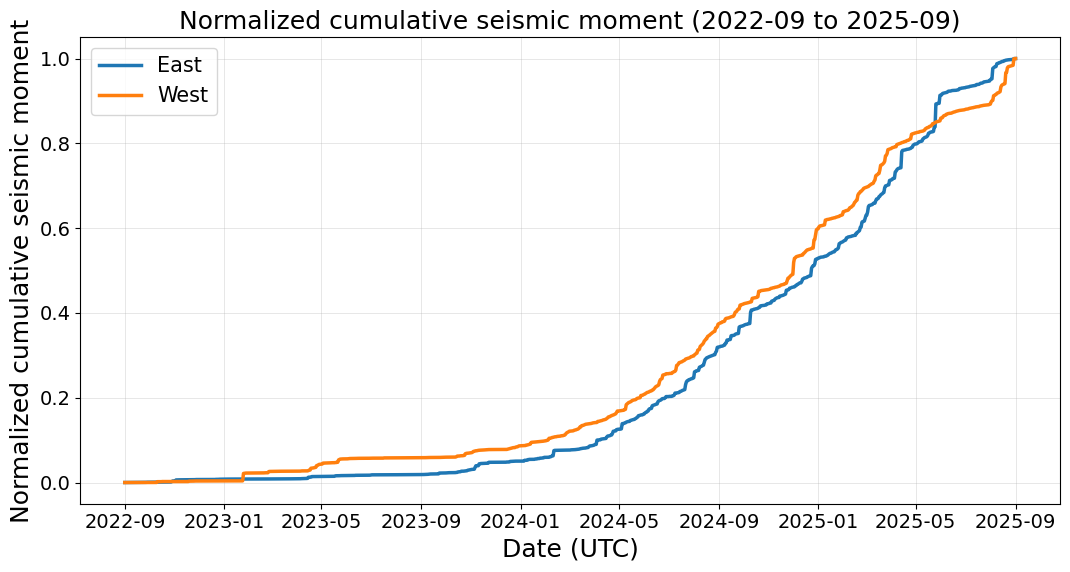

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from scipy.io import loadmat

# Load MAT
m = loadmat("../Data/ForMaleenV4.mat", squeeze_me=True, struct_as_record=False)
S = np.ravel(m["S"])

def matlab_datenum_to_datetime(dn_arr):
    dn = np.asarray(dn_arr, dtype=np.float64)
    days = np.floor(dn).astype(np.int64)
    frac = dn - days
    base_ord = np.array([dt.datetime.fromordinal(int(d)) for d in days], dtype=object)
    delta_frac = np.array([dt.timedelta(days=float(f)) for f in frac], dtype=object)
    out = base_ord + delta_frac - np.array([dt.timedelta(days=366)] * len(dn), dtype=object)
    return pd.to_datetime(out)

time_dn = np.array([getattr(x, "time", np.nan) for x in S], dtype=np.float64)
lat = np.array([getattr(x, "lat", np.nan) for x in S], dtype=np.float64)
lon = np.array([getattr(x, "lon", np.nan) for x in S], dtype=np.float64)
Mw = np.array([getattr(x, "Mw", np.nan) for x in S], dtype=np.float64)

time_dt = matlab_datenum_to_datetime(time_dn).tz_localize("UTC")

df = pd.DataFrame({"time_utc": time_dt, "lat": lat, "lon": lon, "Mw": Mw})
df["time_utc"] = pd.to_datetime(df["time_utc"], utc=True, errors="coerce")
df["lon_w"] = -df["lon"].astype(float)

# West and East polygons as boxes (°W)
w_latmin, w_latmax = 45.930, 45.950
w_lonmin, w_lonmax = -130.029, -130.008

e_latmin, e_latmax = 45.930, 45.970
e_lonmin, e_lonmax = -130.0015, -129.975

# Time window 2022-09 to 2025-09
TMIN = pd.Timestamp("2022-09-01", tz="UTC")
TMAX = pd.Timestamp("2025-09-01", tz="UTC")

df = df[df["time_utc"].notna() & df["Mw"].notna()].copy()
df = df[(df["time_utc"] >= TMIN) & (df["time_utc"] <= TMAX)]

west = df[
    np.isfinite(df["lon_w"].to_numpy())
    & np.isfinite(df["lat"].to_numpy())
    & (df["lon_w"] >= w_lonmin) & (df["lon_w"] <= w_lonmax)
    & (df["lat"] >= w_latmin) & (df["lat"] <= w_latmax)
].copy()

east = df[
    np.isfinite(df["lon_w"].to_numpy())
    & np.isfinite(df["lat"].to_numpy())
    & (df["lon_w"] >= e_lonmin) & (df["lon_w"] <= e_lonmax)
    & (df["lat"] >= e_latmin) & (df["lat"] <= e_latmax)
].copy()

# Moment conversion: log10(M0 [N·m]) = 1.5*Mw + 9.1
def mw_to_m0(mw):
    mw = np.asarray(mw, dtype=float)
    return 10 ** (1.5 * mw + 9.1)

west["M0_Nm"] = mw_to_m0(west["Mw"].to_numpy())
east["M0_Nm"] = mw_to_m0(east["Mw"].to_numpy())

# Daily summed moment and cumulative
all_days = pd.date_range(TMIN.floor("D"), TMAX.floor("D"), freq="D", tz="UTC")

west_daily_m0 = (
    west.groupby(west["time_utc"].dt.floor("D"))["M0_Nm"]
    .sum()
    .reindex(all_days, fill_value=0.0)
)
east_daily_m0 = (
    east.groupby(east["time_utc"].dt.floor("D"))["M0_Nm"]
    .sum()
    .reindex(all_days, fill_value=0.0)
)

west_cum_m0 = west_daily_m0.cumsum()
east_cum_m0 = east_daily_m0.cumsum()

# -----------------------------
# Normalize (pick ONE option)
# -----------------------------

# Option A (recommended): each curve normalized by its own final cumulative moment -> both end at 1
west_den = float(west_cum_m0.iloc[-1])
east_den = float(east_cum_m0.iloc[-1])
west_cum_norm = west_cum_m0 / west_den if west_den > 0 else west_cum_m0 * 0.0
east_cum_norm = east_cum_m0 / east_den if east_den > 0 else east_cum_m0 * 0.0

# Option B: normalize both by the same denominator (max over both curves)
# denom = float(max(west_cum_m0.max(), east_cum_m0.max()))
# west_cum_norm = west_cum_m0 / denom if denom > 0 else west_cum_m0 * 0.0
# east_cum_norm = east_cum_m0 / denom if denom > 0 else east_cum_m0 * 0.0

# Plot (no explicit colors)
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 15,
})

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(all_days.to_pydatetime(), east_cum_norm.to_numpy(), label="East", linewidth=2.5)
ax.plot(all_days.to_pydatetime(), west_cum_norm.to_numpy(), label="West", linewidth=2.5)

ax.set_xlabel("Date (UTC)")
ax.set_ylabel("Normalized cumulative seismic moment")
ax.set_title("Normalized cumulative seismic moment (2022-09 to 2025-09)")
ax.grid(True, linewidth=0.6, alpha=0.35)
ax.legend(frameon=True)

plt.tight_layout()
# plt.show()


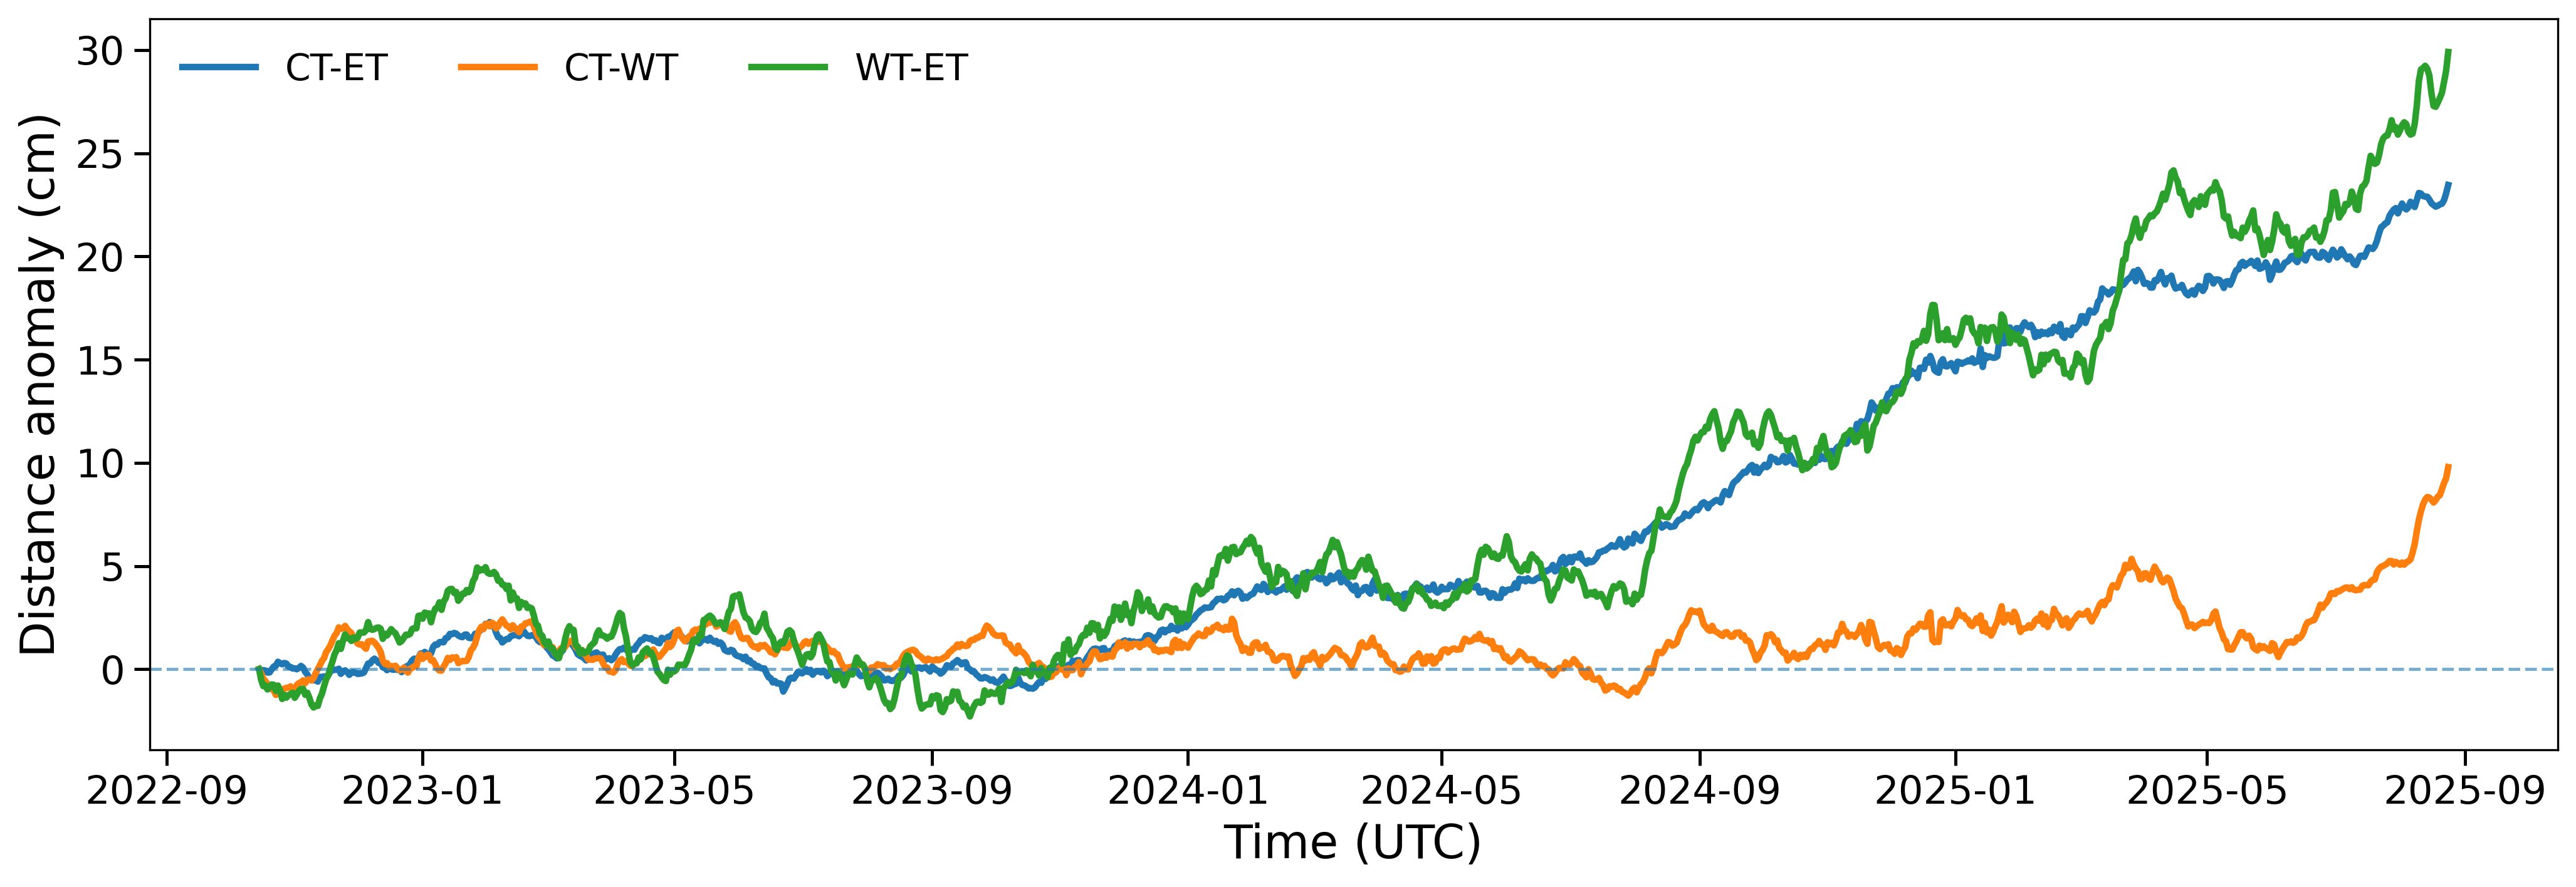

In [141]:
import pandas as pd
import matplotlib.pyplot as plt

path = "../Data/baselines_fit_outputs.csv"
df = pd.read_csv(path)

# identify time column
time_col = None
for c in ["Record Time", "RecordTime", "time", "Time", "date", "Date", "Unnamed: 0"]:
    if c in df.columns:
        time_col = c
        break
if time_col is None:
    time_col = df.columns[0]

t = pd.to_datetime(df[time_col], utc=True, errors="coerce")
df = df.assign(Time=t).dropna(subset=["Time"]).set_index("Time").sort_index()

cols = ["CE_deseason_PcKept", "WC_deseason_PcKept", "WE_deseason_PcKept"]
plot_df = df[cols].dropna()

# anomaly from the first common timestamp (each starts at 0)
anom = plot_df.copy()
for c in cols:
    anom[c] = anom[c] - float(anom[c].iloc[0])

import matplotlib.pyplot as plt

# ---- publication-style defaults ----
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
})

# Map your baseline names (after the replace) to desired legend labels
label_map = {
    "CE": "CT-ET",
    "WC": "CT-WT",
    "WE": "WT-ET",
    # if your cols are named differently, add keys here
}

fig, ax = plt.subplots(figsize=(14, 5), dpi=300)

for c in cols:
    base = c.replace("_deseason_PcKept", "")
    ax.plot(anom.index, anom[c], linewidth=2.5, label=label_map.get(base, base))

ax.axhline(0, lw=1.2, ls="--", alpha=0.6)
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Distance anomaly (cm)")
#ax.set_title("Seasonality-removed baselines")

ax.tick_params(axis="both", which="major", length=6, width=1.2)
ax.legend(frameon=False, ncol=3, loc="upper left")
fig.tight_layout()
plt.show()


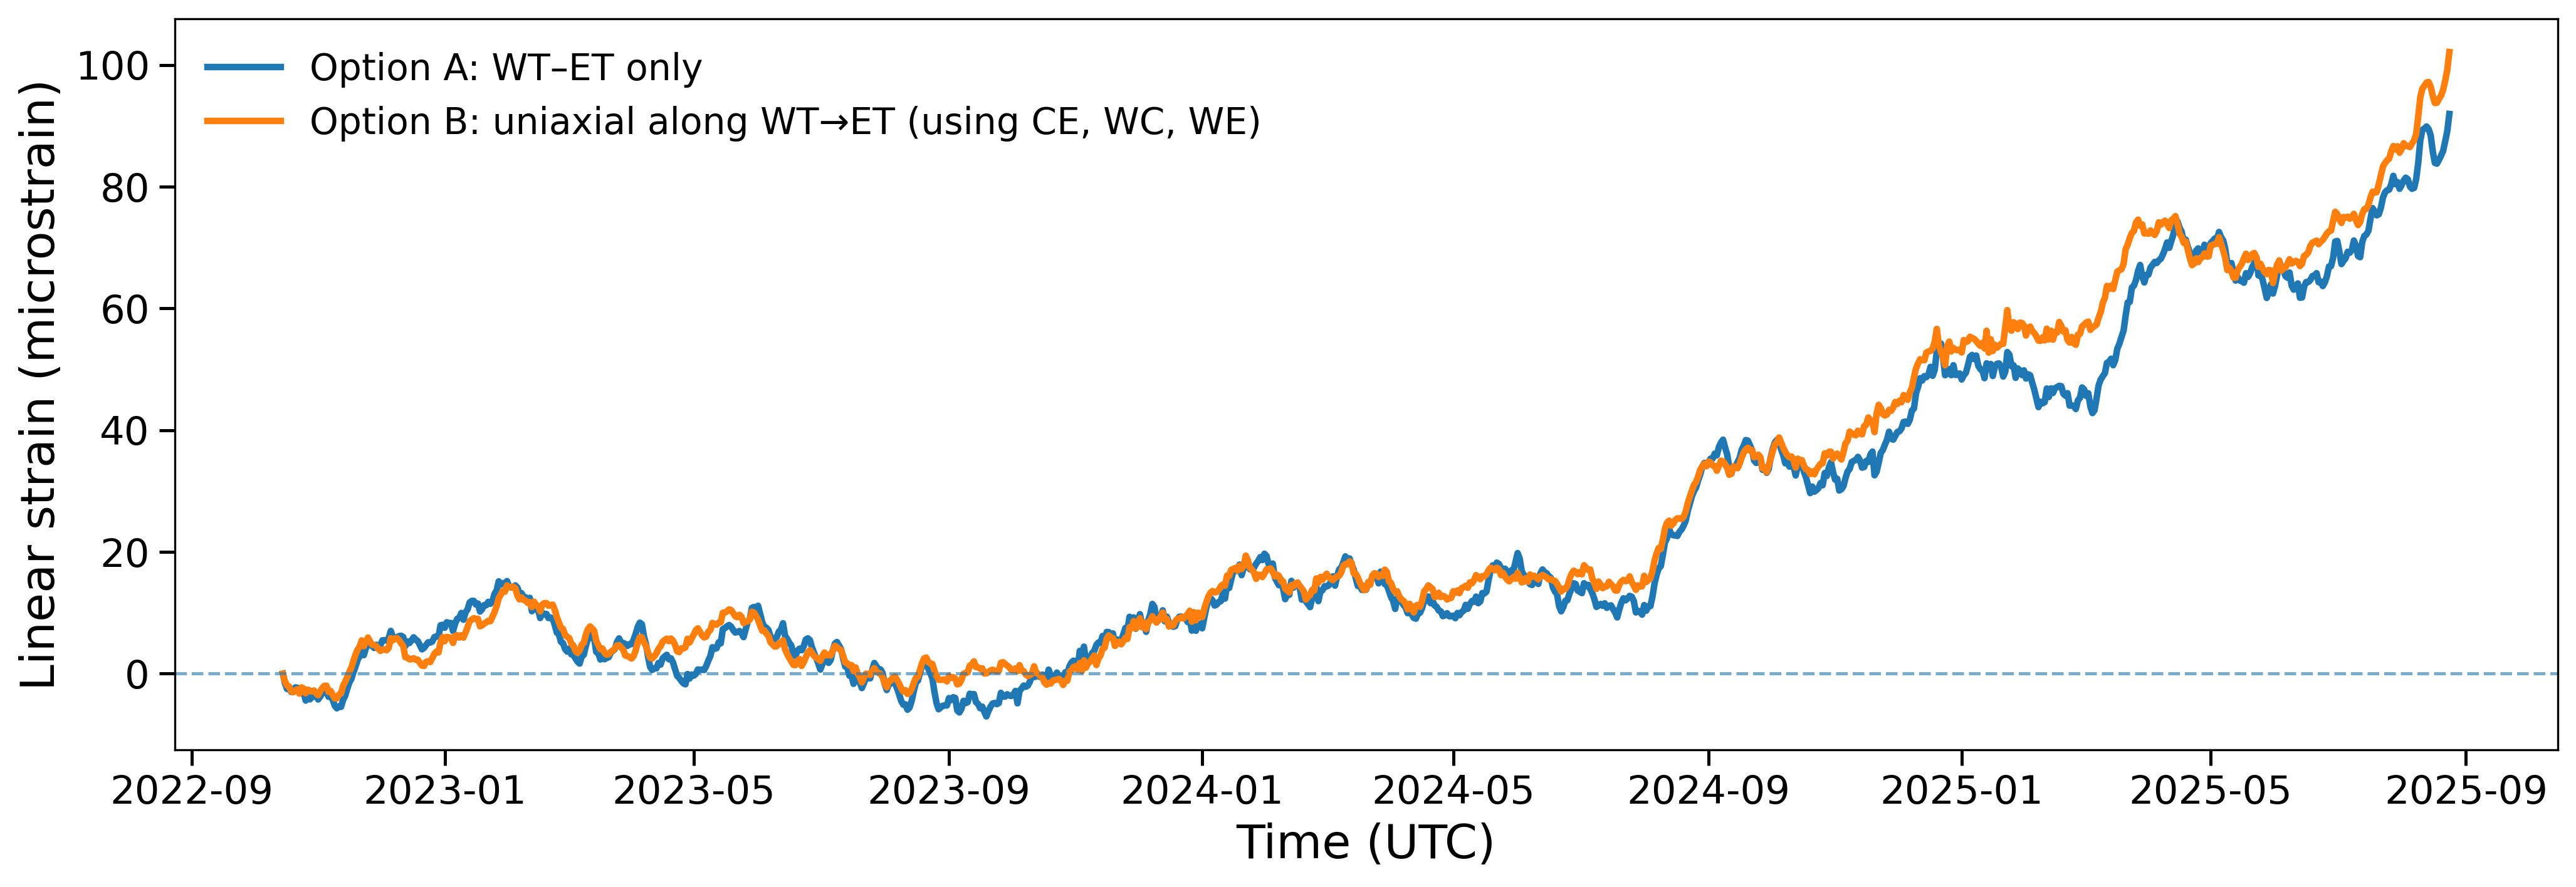

In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------
# Station locations (deg)
# --------------------------
stations = {
    "ET": (45.96257971, -129.9910622),
    "WT": (45.94700845, -130.0265777),
    "NT": (45.95882833, -130.0114997),
}

# --------------------------
# Helpers: geodesic distance + azimuth
# --------------------------
def _try_pyproj_geod():
    try:
        from pyproj import Geod
        return Geod(ellps="WGS84")
    except Exception:
        return None

_GEOD = _try_pyproj_geod()

def geodesic_dist_m_and_az_deg(lat1, lon1, lat2, lon2):
    """
    Returns:
      dist_m : distance (meters)
      az12   : forward azimuth from (1)->(2), degrees clockwise from North
    """
    if _GEOD is not None:
        az12, az21, dist_m = _GEOD.inv(lon1, lat1, lon2, lat2)
        # pyproj.Geod.inv returns azimuths in degrees, dist in meters
        return dist_m, az12
    else:
        # fallback: spherical approx (good enough at ~km scale)
        R = 6371000.0
        phi1, lam1 = np.radians(lat1), np.radians(lon1)
        phi2, lam2 = np.radians(lat2), np.radians(lon2)
        dphi = phi2 - phi1
        dlam = lam2 - lam1
        a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
        dist_m = 2*R*np.arcsin(np.sqrt(a))

        # forward azimuth
        y = np.sin(dlam) * np.cos(phi2)
        x = np.cos(phi1)*np.sin(phi2) - np.sin(phi1)*np.cos(phi2)*np.cos(dlam)
        az = np.degrees(np.arctan2(y, x))  # from North, clockwise
        return dist_m, az

def az_to_unit_EN(az_deg):
    """azimuth (clockwise from North) -> unit vector in (E, N)."""
    az = np.radians(az_deg)
    return np.array([np.sin(az), np.cos(az)], dtype=float)

# --------------------------
# Read your baseline file
# --------------------------
path = "../Data/baselines_fit_outputs.csv"
df = pd.read_csv(path)

# identify time column
time_col = None
for c in ["Record Time", "RecordTime", "time", "Time", "date", "Date", "Unnamed: 0"]:
    if c in df.columns:
        time_col = c
        break
if time_col is None:
    time_col = df.columns[0]

t = pd.to_datetime(df[time_col], utc=True, errors="coerce")
df = df.assign(Time=t).dropna(subset=["Time"]).set_index("Time").sort_index()

cols = ["CE_deseason_PcKept", "WC_deseason_PcKept", "WE_deseason_PcKept"]
plot_df = df[cols].dropna()

# anomaly from the first common timestamp (each starts at 0)
anom = plot_df.copy()
for c in cols:
    anom[c] = anom[c] - float(anom[c].iloc[0])

# --------------------------
# Map columns -> station pairs
# (Assuming your CE=NT-ET, WC=NT-WT, WE=WT-ET)
# --------------------------
pair_map = {
    "CE_deseason_PcKept": ("NT", "ET"),
    "WC_deseason_PcKept": ("NT", "WT"),
    "WE_deseason_PcKept": ("WT", "ET"),
}

# Precompute reference lengths (L0) and directions for each baseline
L0_cm = {}
n_hat_EN = {}  # unit baseline direction in EN

for col, (s1, s2) in pair_map.items():
    lat1, lon1 = stations[s1]
    lat2, lon2 = stations[s2]
    dist_m, az12 = geodesic_dist_m_and_az_deg(lat1, lon1, lat2, lon2)
    L0_cm[col] = dist_m * 100.0
    n_hat_EN[col] = az_to_unit_EN(az12)

# --------------------------
# OPTION A: linear strain using WE (WT-ET) only
# --------------------------
WE_col = "WE_deseason_PcKept"
strain_A = anom[WE_col].values / L0_cm[WE_col]  # unitless
strain_A_micro = 1e6 * strain_A

# --------------------------
# OPTION B: uniaxial strain along WT->ET axis using all baselines
# Model: e_ij(t) ~ eps(t) * cos^2(alpha_ij)
# where e_ij = ΔL/L0
# --------------------------
a_hat = n_hat_EN[WE_col]  # axis is WT->ET direction (unit)

# fractional extensions e_ij(t) for each baseline (unitless)
e = {}
cos2 = {}
for col in cols:
    e[col] = anom[col].values / L0_cm[col]
    ca = float(np.dot(n_hat_EN[col], a_hat))  # cos(alpha)
    cos2[col] = ca * ca

# Optionally drop baselines nearly perpendicular to axis (they carry little info)
# You can tighten/loosen this threshold.
COS2_MIN = 0.05

use_cols = [c for c in cols if cos2[c] >= COS2_MIN]
if len(use_cols) == 0:
    raise RuntimeError("All baselines are nearly perpendicular to WT->ET axis; lower COS2_MIN.")

# equal weights (set to 1/sigma^2 if you have uncertainties)
w = {c: 1.0 for c in use_cols}

num = np.zeros(len(anom), dtype=float)
den = np.zeros(len(anom), dtype=float)
for c in use_cols:
    num += w[c] * cos2[c] * e[c]
    den += w[c] * (cos2[c] ** 2)

strain_B = num / den
strain_B_micro = 1e6 * strain_B

# --------------------------
# Plot (publication-ish)
# --------------------------
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
})

fig, ax = plt.subplots(figsize=(14, 5), dpi=300)

ax.plot(anom.index, strain_A_micro, lw=2.5, label="WT–ET only")
ax.plot(anom.index, strain_B_micro, lw=2.5, label=f"uniaxial along WT→ET (using {', '.join([c.split('_')[0] for c in use_cols])})")

ax.axhline(0, lw=1.2, ls="--", alpha=0.6)
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Linear strain (microstrain)")
ax.tick_params(axis="both", which="major", length=6, width=1.2)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()


In [181]:
import pandas as pd
import matplotlib.pyplot as plt

path = "../Data/baselines_fit_outputs.csv"
df = pd.read_csv(path)

# -----------------------------
# Build time index (same as you)
# -----------------------------
time_col = None
for c in ["Record Time", "RecordTime", "time", "Time", "date", "Date", "Unnamed: 0"]:
    if c in df.columns:
        time_col = c
        break
if time_col is None:
    time_col = df.columns[0]

t = pd.to_datetime(df[time_col], utc=True, errors="coerce")
df = df.assign(Time=t).dropna(subset=["Time"]).set_index("Time").sort_index()

cols = ["CE_deseason_PcKept", "WC_deseason_PcKept", "WE_deseason_PcKept"]
plot_df = df[cols].dropna()

# anomaly from the first common timestamp (each starts at 0)
anom = plot_df.copy()
for c in cols:
    anom[c] = anom[c] - float(anom[c].iloc[0])

# -----------------------------
# 7-day lookback mean function
# -----------------------------
def mean_prev_7d(anom_df: pd.DataFrame, date, columns=None, closed="left"):
    """
    Mean over [date-7days, date) by default (closed='left' excludes 'date').
    date can be str, Timestamp, datetime.
    """
    date = pd.to_datetime(date, utc=True)
    start = date - pd.Timedelta(days=1)

    if columns is None:
        columns = list(anom_df.columns)
    elif isinstance(columns, str):
        columns = [columns]

    window = anom_df.loc[start:date]

    # If you want strictly "before date" (exclude exact date), drop it if present
    if closed == "left" and date in window.index:
        window = window.loc[window.index < date]

    if window.empty:
        return pd.Series({c: float("nan") for c in columns})

    return window[columns].mean()

# -----------------------------
# Example usage
# -----------------------------
target_date = "2025-08-09"  # <-- change this
m = mean_prev_7d(anom, target_date)  # all three cols
print(f"7-day mean before {pd.to_datetime(target_date, utc=True)}")
print(m)

# Single column:
m_we = mean_prev_7d(anom, target_date, columns="WE_deseason_PcKept")
print("\nWT-ET only:", float(m_we.iloc[0]))


7-day mean before 2025-08-09 00:00:00+00:00
CE_deseason_PcKept    22.393446
WC_deseason_PcKept     6.062353
WE_deseason_PcKept    26.411962
dtype: float64

WT-ET only: 26.4119621917489


In [174]:
df

,Unnamed: 0,CE_MA30,WC_MA30,WE_MA30,Pc_daily,CE_season_fit,CE_deseason_PcKept,WC_season_fit,WC_deseason_PcKept,WE_season_fit,WE_deseason_PcKept
Time,,,,,,,,,,,
2022-10-15 00:00:00+00:00,2022-10-15 00:00:00+00:00,164208.790033,176562.096506,326019.388480,1.297408,1.538559,164207.251474,1.362685,176560.733821,2.927502,326016.460978
2022-10-16 00:00:00+00:00,2022-10-16 00:00:00+00:00,164208.635324,176561.885220,326018.821236,1.278389,1.522767,164207.112556,1.352393,176560.532827,2.879456,326015.941779
2022-10-17 00:00:00+00:00,2022-10-17 00:00:00+00:00,164208.713562,176561.606747,326018.475142,1.269642,1.506526,164207.207037,1.341700,176560.265047,2.830559,326015.644584
2022-10-18 00:00:00+00:00,2022-10-18 00:00:00+00:00,164208.678573,176561.498998,326018.463601,1.264785,1.489838,164207.188735,1.330610,176560.168387,2.780823,326015.682777
2022-10-19 00:00:00+00:00,2022-10-19 00:00:00+00:00,164208.564870,176561.324938,326018.215042,1.246639,1.472709,164207.092161,1.319127,176560.005811,2.730265,326015.484777
...,...,...,...,...,...,...,...,...,...,...,...
2025-08-20 00:00:00+00:00,2025-08-20 00:00:00+00:00,164231.392622,176570.425826,326048.081345,-2.234295,1.624295,164229.768327,1.262840,176569.162985,3.947213,326044.134132
2025-08-21 00:00:00+00:00,2025-08-21 00:00:00+00:00,164231.440207,176570.738109,326048.350842,-2.244327,1.636782,164229.803424,1.276047,176569.462062,3.960509,326044.390332
2025-08-22 00:00:00+00:00,2025-08-22 00:00:00+00:00,164231.621636,176571.042182,326048.878043,-2.239196,1.648785,164229.972851,1.288877,176569.753306,3.972634,326044.905409


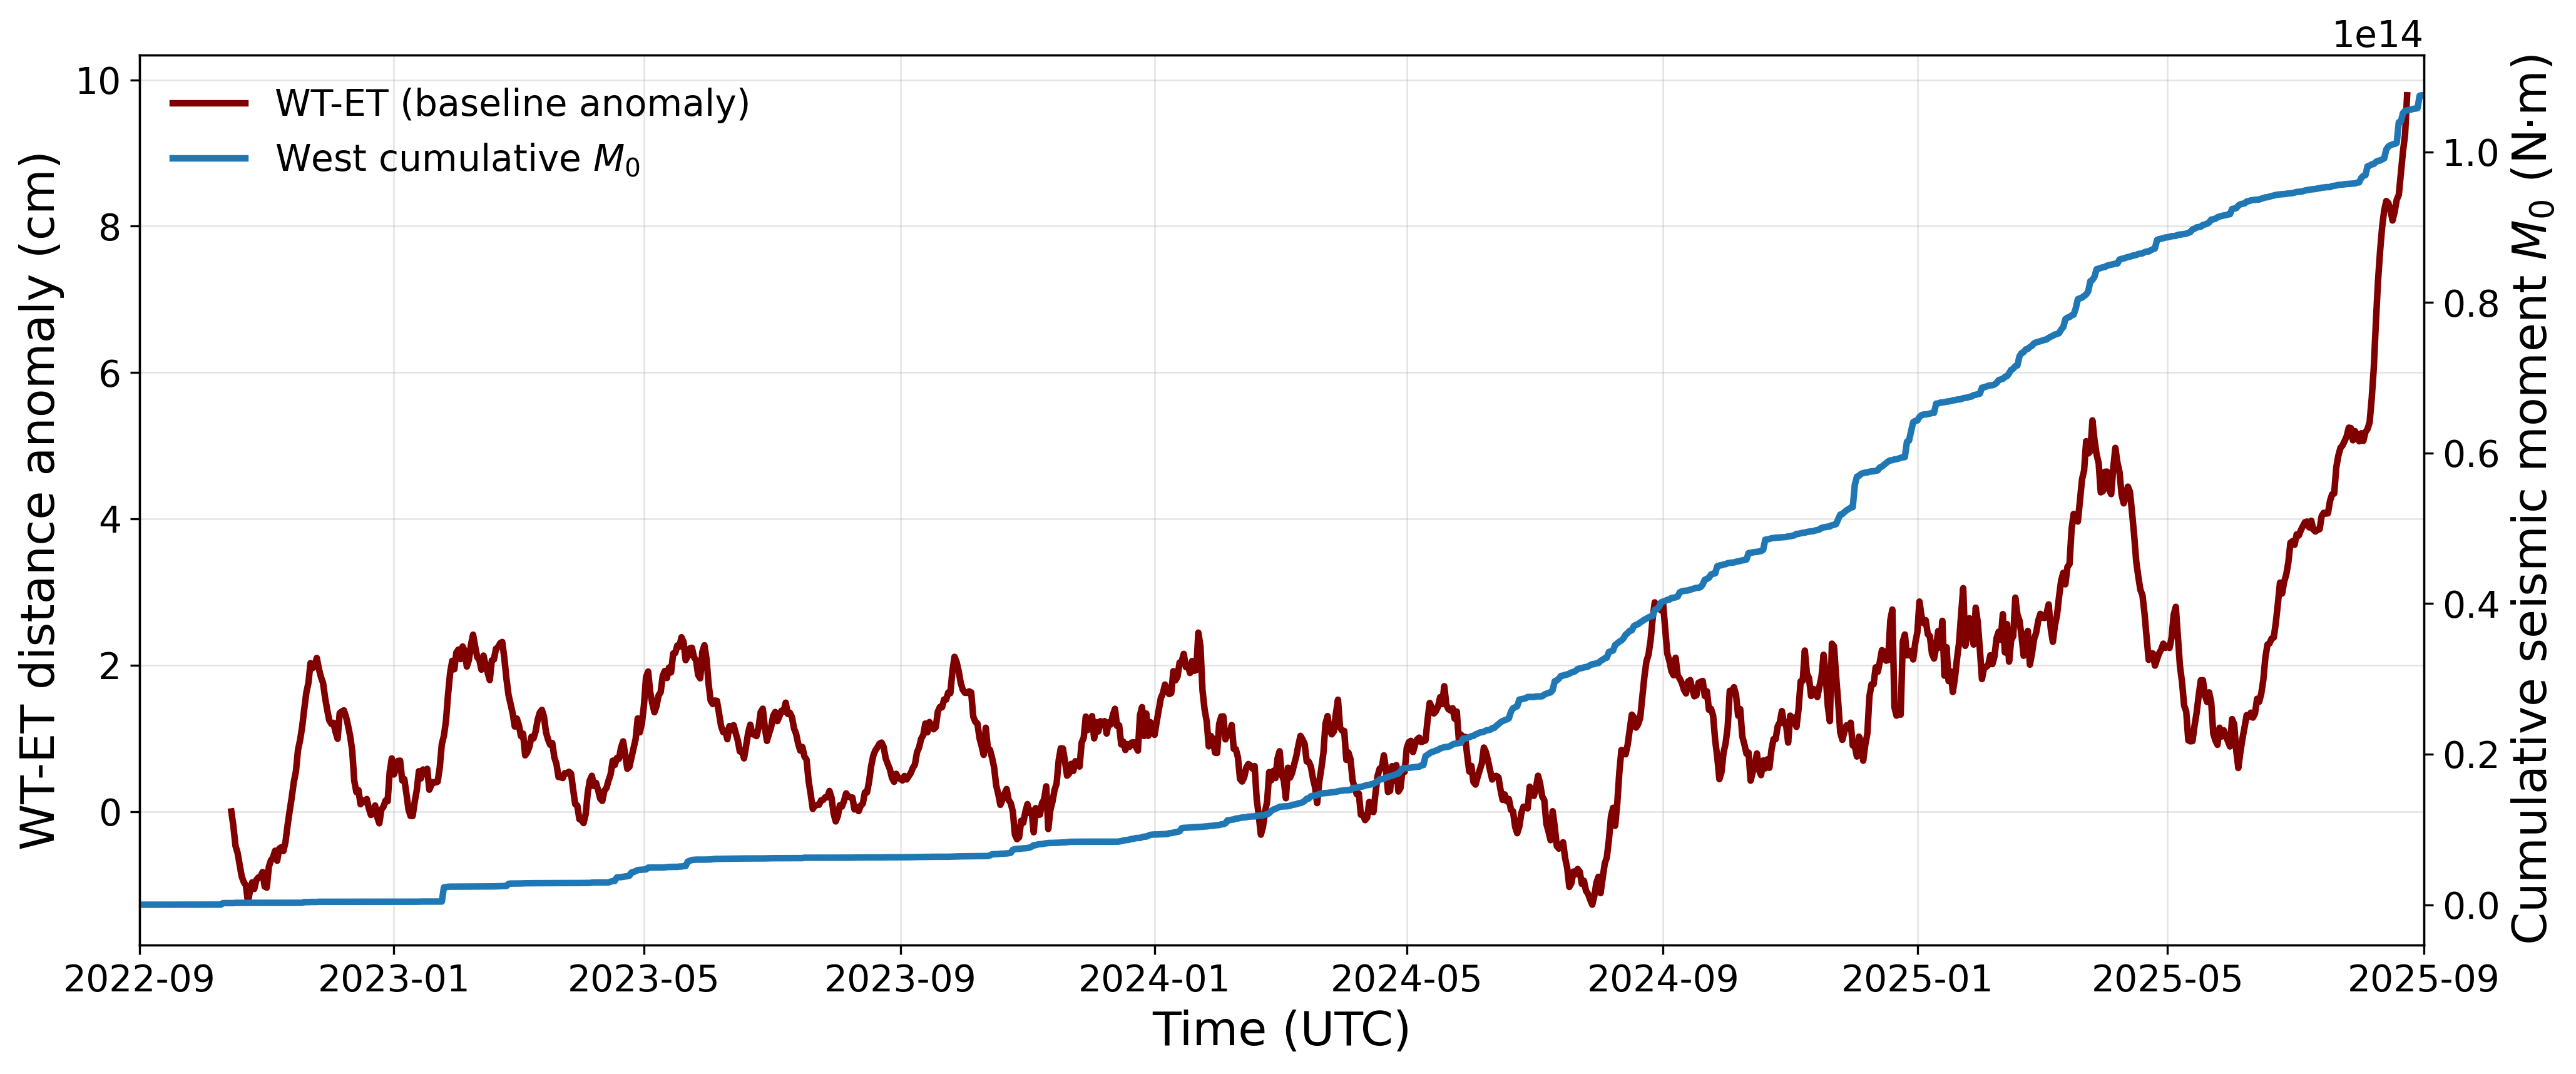

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from scipy.io import loadmat

# -----------------------------
# USER FILES
# -----------------------------
MAT_PATH = "../Data/ForMaleenV4.mat"
BASELINE_CSV = "../Data/baselines_fit_outputs.csv"

# Time window
TMIN = pd.Timestamp("2022-09-01", tz="UTC")
TMAX = pd.Timestamp("2025-09-01", tz="UTC")

# West polygon box (°W, i.e., negative longitude)
w_latmin, w_latmax = 45.930, 45.950
w_lonmin, w_lonmax = -130.029, -130.008

# -----------------------------
# Helpers
# -----------------------------
def matlab_datenum_to_datetime(dn_arr):
    dn = np.asarray(dn_arr, dtype=np.float64)
    days = np.floor(dn).astype(np.int64)
    frac = dn - days
    base_ord = np.array([dt.datetime.fromordinal(int(d)) for d in days], dtype=object)
    delta_frac = np.array([dt.timedelta(days=float(f)) for f in frac], dtype=object)
    out = base_ord + delta_frac - np.array([dt.timedelta(days=366)] * len(dn), dtype=object)
    return pd.to_datetime(out)

# Moment conversion: log10(M0 [N·m]) = 1.5*Mw + 9.1
def mw_to_m0(mw):
    mw = np.asarray(mw, dtype=float)
    return 10 ** (1.5 * mw + 9.1)

def find_time_col(df):
    for c in ["Record Time", "RecordTime", "time", "Time", "date", "Date", "Unnamed: 0"]:
        if c in df.columns:
            return c
    return df.columns[0]

# -----------------------------
# 1) Western cumulative moment
# -----------------------------
m = loadmat(MAT_PATH, squeeze_me=True, struct_as_record=False)
S = np.ravel(m["S"])

time_dn = np.array([getattr(x, "time", np.nan) for x in S], dtype=np.float64)
lat     = np.array([getattr(x, "lat",  np.nan) for x in S], dtype=np.float64)
lon     = np.array([getattr(x, "lon",  np.nan) for x in S], dtype=np.float64)
Mw      = np.array([getattr(x, "Mw",   np.nan) for x in S], dtype=np.float64)

time_dt = matlab_datenum_to_datetime(time_dn).tz_localize("UTC")

eq = pd.DataFrame({"time_utc": time_dt, "lat": lat, "lon": lon, "Mw": Mw})
eq["time_utc"] = pd.to_datetime(eq["time_utc"], utc=True, errors="coerce")
eq["lon_w"] = -eq["lon"].astype(float)  # your convention (kept exactly)

eq = eq[eq["time_utc"].notna() & eq["Mw"].notna()].copy()
eq = eq[(eq["time_utc"] >= TMIN) & (eq["time_utc"] <= TMAX)]

west = eq[
    np.isfinite(eq["lon_w"].to_numpy())
    & np.isfinite(eq["lat"].to_numpy())
    & (eq["lon_w"] >= w_lonmin) & (eq["lon_w"] <= w_lonmax)
    & (eq["lat"]   >= w_latmin) & (eq["lat"]   <= w_latmax)
].copy()

west["M0_Nm"] = mw_to_m0(west["Mw"].to_numpy())

all_days = pd.date_range(TMIN.floor("D"), TMAX.floor("D"), freq="D", tz="UTC")
west_daily_m0 = (
    west.groupby(west["time_utc"].dt.floor("D"))["M0_Nm"]
    .sum()
    .reindex(all_days, fill_value=0.0)
)
west_cum_m0 = west_daily_m0.cumsum()

# -----------------------------
# 2) WT–ET baseline anomaly (WE)
# -----------------------------
b = pd.read_csv(BASELINE_CSV)
time_col = find_time_col(b)
t = pd.to_datetime(b[time_col], utc=True, errors="coerce")
b = b.assign(Time=t).dropna(subset=["Time"]).set_index("Time").sort_index()

we_col = "WC_deseason_PcKept"
if we_col not in b.columns:
    raise KeyError(f"Could not find '{we_col}' in {BASELINE_CSV}. Available cols:\n{list(b.columns)}")

we = b[[we_col]].dropna().copy()
we = we[(we.index >= TMIN) & (we.index <= TMAX)]
we_anom = we[we_col] - float(we[we_col].iloc[0])  # start at 0

# -----------------------------
# Plot: WT–ET baseline vs West cumulative moment
# -----------------------------
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

fig, ax1 = plt.subplots(figsize=(14, 6), dpi=300)

# Left axis: baseline anomaly
l1, = ax1.plot(we_anom.index, we_anom.to_numpy(), linewidth=2.5, label="WT-ET (baseline anomaly)", color ="maroon")
ax1.set_xlabel("Time (UTC)")
ax1.set_ylabel("WT-ET distance anomaly (cm)")
ax1.grid(True, linewidth=0.6, alpha=0.35)

# Right axis: cumulative moment
ax2 = ax1.twinx()
l2, = ax2.plot(all_days, west_cum_m0.to_numpy(), linewidth=2.5, label="West cumulative $M_0$")
ax2.set_ylabel("Cumulative seismic moment $M_0$ (N·m)")

# Shared limits
ax1.set_xlim(TMIN, TMAX)

# One combined legend
lines = [l1, l2]
labels = [ln.get_label() for ln in lines]
ax1.legend(lines, labels, frameon=False, loc="upper left")

fig.tight_layout()
plt.show()


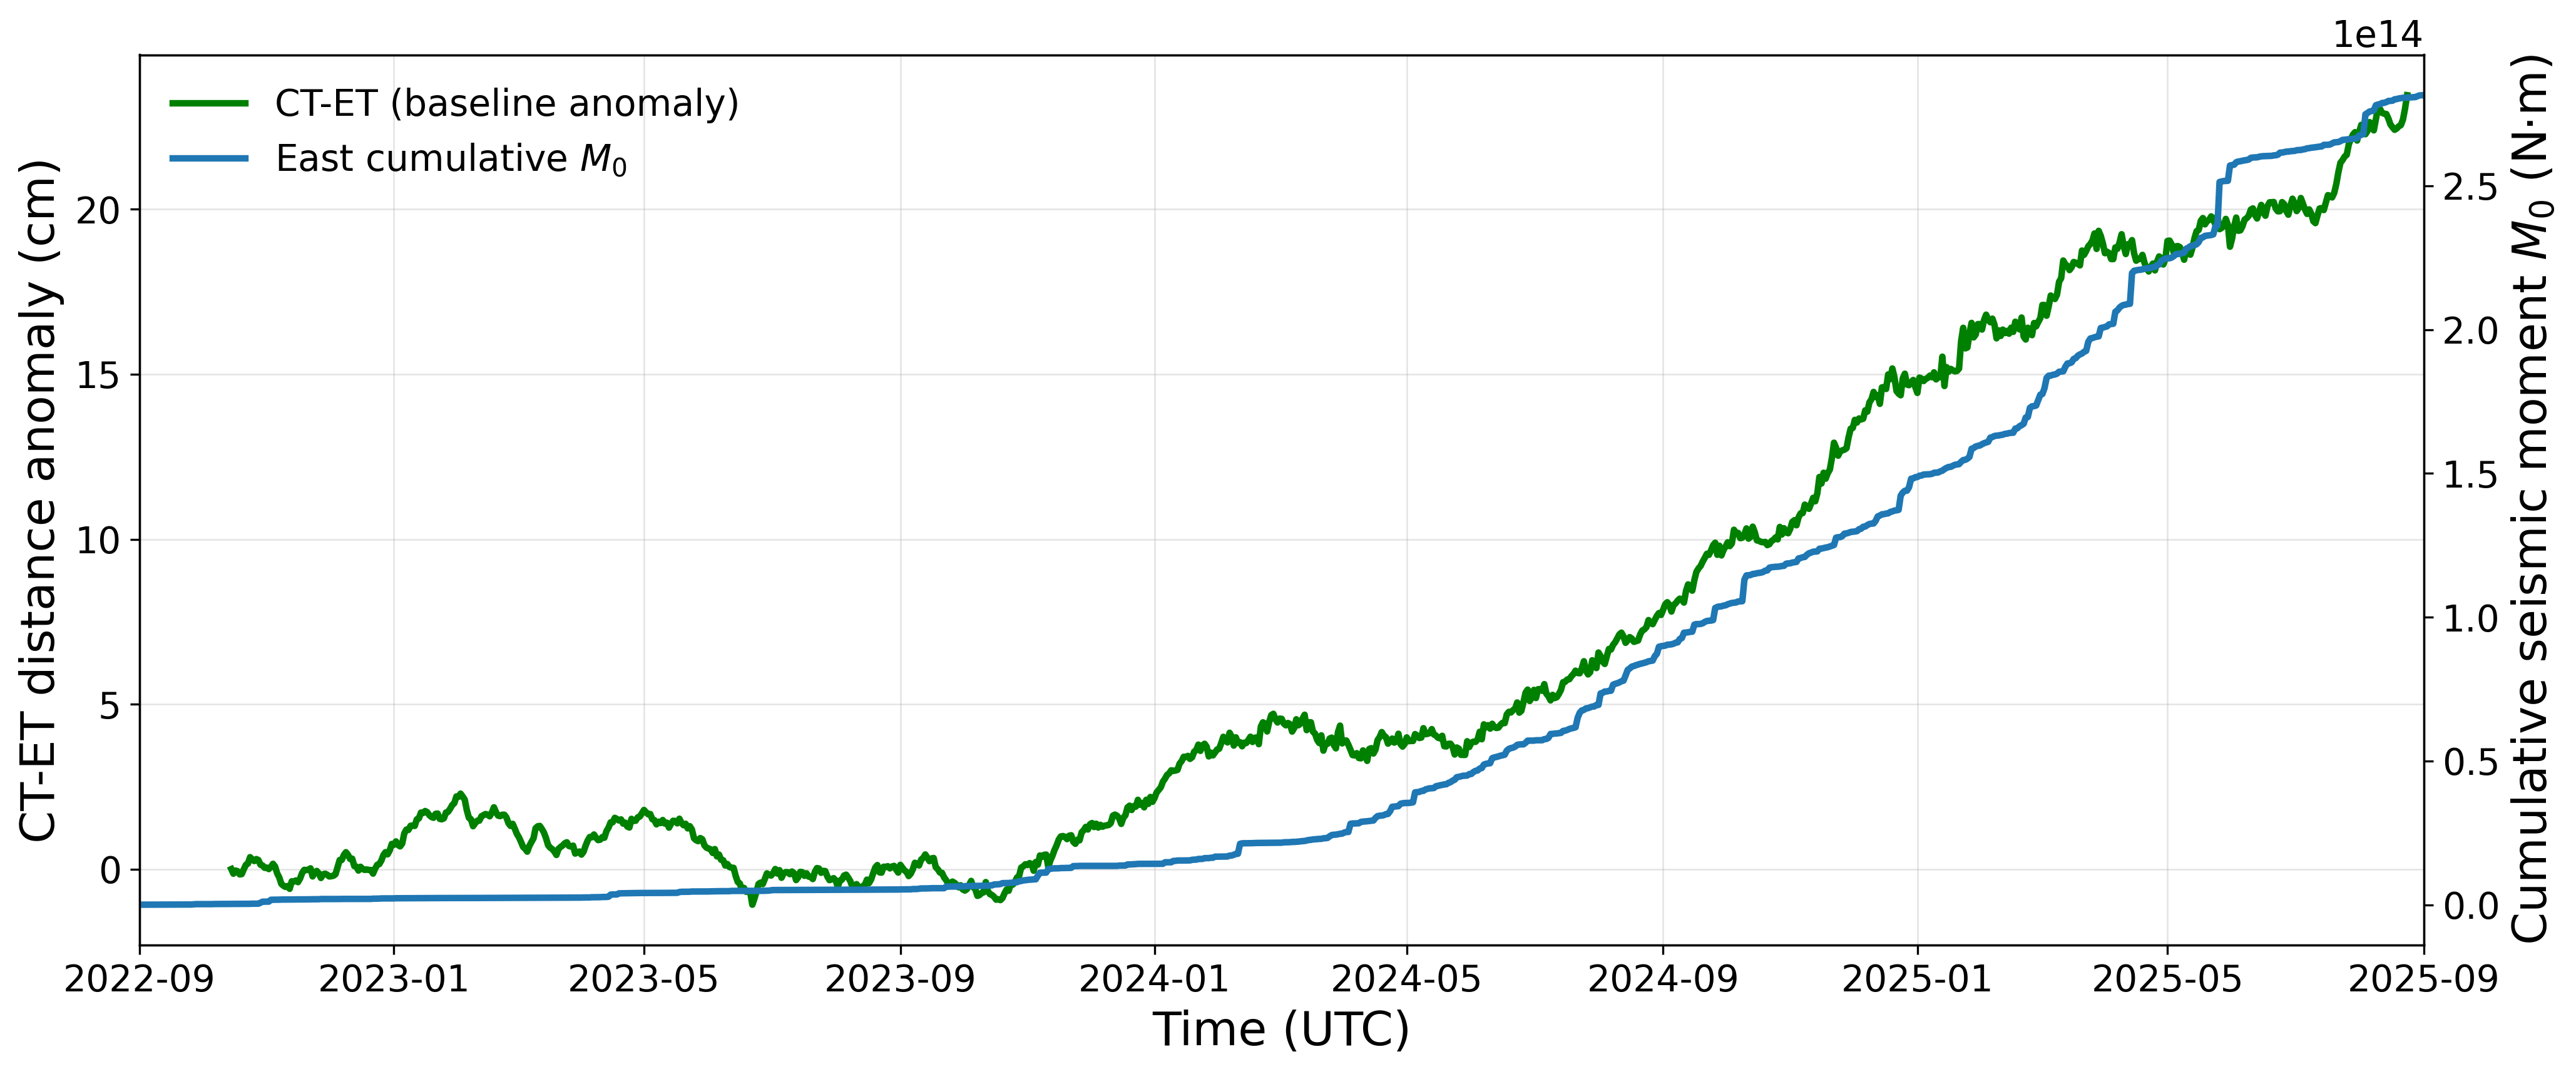

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from scipy.io import loadmat

# -----------------------------
# USER FILES
# -----------------------------
MAT_PATH = "../Data/ForMaleenV4.mat"
BASELINE_CSV = "../Data/baselines_fit_outputs.csv"

# Time window
TMIN = pd.Timestamp("2022-09-01", tz="UTC")
TMAX = pd.Timestamp("2025-09-01", tz="UTC")

# East polygon box (°W, i.e., negative longitude)
e_latmin, e_latmax = 45.930, 45.970
e_lonmin, e_lonmax = -130.0015, -129.975

# -----------------------------
# Helpers
# -----------------------------
def matlab_datenum_to_datetime(dn_arr):
    dn = np.asarray(dn_arr, dtype=np.float64)
    days = np.floor(dn).astype(np.int64)
    frac = dn - days
    base_ord = np.array([dt.datetime.fromordinal(int(d)) for d in days], dtype=object)
    delta_frac = np.array([dt.timedelta(days=float(f)) for f in frac], dtype=object)
    out = base_ord + delta_frac - np.array([dt.timedelta(days=366)] * len(dn), dtype=object)
    return pd.to_datetime(out)

# Moment conversion: log10(M0 [N·m]) = 1.5*Mw + 9.1
def mw_to_m0(mw):
    mw = np.asarray(mw, dtype=float)
    return 10 ** (1.5 * mw + 9.1)

def find_time_col(df):
    for c in ["Record Time", "RecordTime", "time", "Time", "date", "Date", "Unnamed: 0"]:
        if c in df.columns:
            return c
    return df.columns[0]

# -----------------------------
# 1) Eastern cumulative moment
# -----------------------------
m = loadmat(MAT_PATH, squeeze_me=True, struct_as_record=False)
S = np.ravel(m["S"])

time_dn = np.array([getattr(x, "time", np.nan) for x in S], dtype=np.float64)
lat     = np.array([getattr(x, "lat",  np.nan) for x in S], dtype=np.float64)
lon     = np.array([getattr(x, "lon",  np.nan) for x in S], dtype=np.float64)
Mw      = np.array([getattr(x, "Mw",   np.nan) for x in S], dtype=np.float64)

time_dt = matlab_datenum_to_datetime(time_dn).tz_localize("UTC")

eq = pd.DataFrame({"time_utc": time_dt, "lat": lat, "lon": lon, "Mw": Mw})
eq["time_utc"] = pd.to_datetime(eq["time_utc"], utc=True, errors="coerce")
eq["lon_w"] = -eq["lon"].astype(float)  # your convention (kept exactly)

eq = eq[eq["time_utc"].notna() & eq["Mw"].notna()].copy()
eq = eq[(eq["time_utc"] >= TMIN) & (eq["time_utc"] <= TMAX)]

east = eq[
    np.isfinite(eq["lon_w"].to_numpy())
    & np.isfinite(eq["lat"].to_numpy())
    & (eq["lon_w"] >= e_lonmin) & (eq["lon_w"] <= e_lonmax)
    & (eq["lat"]   >= e_latmin) & (eq["lat"]   <= e_latmax)
].copy()

east["M0_Nm"] = mw_to_m0(east["Mw"].to_numpy())

all_days = pd.date_range(TMIN.floor("D"), TMAX.floor("D"), freq="D", tz="UTC")
east_daily_m0 = (
    east.groupby(east["time_utc"].dt.floor("D"))["M0_Nm"]
    .sum()
    .reindex(all_days, fill_value=0.0)
)
east_cum_m0 = east_daily_m0.cumsum()

# -----------------------------
# 2) CT–ET baseline anomaly (CE)
# -----------------------------
b = pd.read_csv(BASELINE_CSV)
time_col = find_time_col(b)
t = pd.to_datetime(b[time_col], utc=True, errors="coerce")
b = b.assign(Time=t).dropna(subset=["Time"]).set_index("Time").sort_index()

ce_col = "CE_deseason_PcKept"
if ce_col not in b.columns:
    raise KeyError(f"Could not find '{ce_col}' in {BASELINE_CSV}. Available cols:\n{list(b.columns)}")

ce = b[[ce_col]].dropna().copy()
ce = ce[(ce.index >= TMIN) & (ce.index <= TMAX)]
ce_anom = ce[ce_col] - float(ce[ce_col].iloc[0])  # start at 0

# -----------------------------
# Plot: CT–ET baseline vs East cumulative moment
# -----------------------------
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

fig, ax1 = plt.subplots(figsize=(14, 6), dpi=300)

# Left axis: baseline anomaly
l1, = ax1.plot(ce_anom.index, ce_anom.to_numpy(), linewidth=2.5, label="CT-ET (baseline anomaly)",color = "green")
ax1.set_xlabel("Time (UTC)")
ax1.set_ylabel("CT-ET distance anomaly (cm)")
ax1.grid(True, linewidth=0.6, alpha=0.35)

# Right axis: cumulative moment
ax2 = ax1.twinx()
l2, = ax2.plot(all_days, east_cum_m0.to_numpy(), linewidth=2.5, label="East cumulative $M_0$")
ax2.set_ylabel("Cumulative seismic moment $M_0$ (N·m)")

ax1.set_xlim(TMIN, TMAX)

lines = [l1, l2]
labels = [ln.get_label() for ln in lines]
ax1.legend(lines, labels, frameon=False, loc="upper left")

fig.tight_layout()
plt.show()


In [7]:
import pandas as pd
from pathlib import Path
import re

def _canon(s: str) -> str:
    """Lowercase and remove non-alphanumerics for flexible header matching."""
    return re.sub(r'[^0-9a-z]+', '', str(s).lower())

def _attempt_map_columns(df, verbose=True):
    """
    Try to map a file *with headers* to ['time','rawpsi','tide_m','temp'].
    Returns (df_renamed, success_bool).
    """
    # Clean column names
    clean_cols = []
    for c in df.columns:
        c0 = str(c).replace("\ufeff", "").strip()
        c0 = re.sub(r'\s*\(\s*', '(', c0)  # "tide (m)" -> "tide(m)"
        c0 = re.sub(r'\s*\)\s*', ')', c0)  # "temperature (degC )" -> "temperature(degC)"
        clean_cols.append(c0)
    df.columns = clean_cols

    if verbose:
        print("Detected columns:", list(df.columns))

    # Known header variants
    targets = {
        "time":   {"time","datetime","timestamp","date","datestamp"},
        "rawpsi": {"pressurepsi","pressure","psi","pressurespsi","pressure(psi)"},
        "tide_m": {"tide","tidem","tide_m","tide(m)"},
        "temp":   {"temp","temperature","temperaturedegc","temperature(c)","temperature(degc)","tempc"},
    }

    rename_map = {}
    canon_to_src = { _canon(c): c for c in df.columns }

    for want, variants in targets.items():
        found = None
        # Exact variant match
        for v in variants:
            if v in canon_to_src:
                found = canon_to_src[v]
                break
        # Heuristics if needed
        if found is None:
            for k, src in canon_to_src.items():
                if want == "rawpsi" and (k.startswith("pressure") or k.endswith("psi") or "psi" in k):
                    found = src; break
                if want == "tide_m" and ("tide" in k):
                    found = src; break
                if want == "temp" and ("temp" in k or "temperature" in k):
                    found = src; break
                if want == "time" and ("time" in k or "date" in k or "stamp" in k):
                    found = src; break
        if found is not None:
            rename_map[found] = want

    if verbose:
        print("Column mapping:", rename_map)

    df2 = df.rename(columns=rename_map)
    required = ["time","rawpsi","tide_m","temp"]
    success = all(c in df2.columns for c in required)
    return df2, success

def convert_F2025_to_MJ03F(
    infile: str,
    outfile: str = 'MJ03F2025NANO.Data',
    *,
    rho_seawater=1025.0,
    g=9.80665,
    m_per_psi=0.67,        # set to None for physics-accurate (~0.6859215 m/psi)
    write_header=False,    # <<< make output headerless to match your reader
    verbose=True,
):
    """
    Convert an F2025_* pressure/tide/temp file to MJ03F-style:
      input columns (order): Time, Pressure(psi), tide(m), temperature(degC)
      output columns:        time, rawpsi, depth, temp

    depth (m) = rawpsi * m_per_psi - tide(m)
    """
    # Pass 1: try reading with header and map columns
    df = pd.read_csv(infile, sep=None, engine="python")
    df_try, ok = _attempt_map_columns(df.copy(), verbose=verbose)

    # If mapping failed, it's likely headerless: re-read with known schema
    if not ok:
        if verbose:
            print("No usable header detected. Re-reading as headerless...")
        df_try = pd.read_csv(
            infile, sep=None, engine="python",
            header=None, names=["time","rawpsi","tide_m","temp"]
        )

    # Parse types
    df_try["time"] = pd.to_datetime(df_try["time"], errors="coerce")
    df_try = df_try.dropna(subset=["time"]).sort_values("time")
    for c in ["rawpsi","tide_m","temp"]:
        df_try[c] = pd.to_numeric(df_try[c], errors="coerce")

    # If m_per_psi is None, compute physics-based conversion (≈0.6859215 m/psi @ 1025 kg/m³)
    if m_per_psi is None:
        PSI_TO_PA = 6894.757
        m_per_psi = PSI_TO_PA / (rho_seawater * g)

    # Detided depth
    df_try["depth"] = df_try["rawpsi"] * m_per_psi - df_try["tide_m"]

    out = df_try[["time","rawpsi","depth","temp"]].copy()

    # --- Ensure your downstream reader (header=None) is happy ---
    # 1) Format time consistently
    out["time"] = out["time"].dt.strftime("%Y-%m-%d %H:%M:%S")
    # 2) Write without header if requested
    Path(outfile).parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(outfile, index=False, header=write_header)  # <<< key change

    if verbose:
        print(f"m_per_psi used: {m_per_psi:.9f} m/psi")
        print(f"Wrote: {outfile} ({len(out)} rows) | header={write_header}")

    return out, outfile

# --- Run it (edit the filenames if needed) ---
if __name__ == "__main__":
    inpath  = "../Extra_files_fetch/B2025_all.dat"           # your input file
    outpath = "output/drift/MJ03B2025NANO.Data"      # desired output filename
    out_df, out_file = convert_F2025_to_MJ03F(
        inpath, outfile=outpath,
        m_per_psi=0.67, write_header=False, verbose=True
    )
    print(f"Done: {out_file}")


Detected columns: ['2025-01-01 00:00:00', '2274.667690067', '-0.398059994', '3.143778931']
Column mapping: {}
No usable header detected. Re-reading as headerless...
m_per_psi used: 0.670000000 m/psi
Wrote: MJ03B2025NANO.Data (1485526 rows) | header=False
Done: MJ03B2025NANO.Data


In [8]:
combined_df3=pd.read_pickle('/data/wsd02/maleen_data/Data2503.pkl')
combined_df2=pd.read_pickle('/data/wsd02/maleen_data/Data2502.pkl')
combined_df4=pd.read_pickle('/data/wsd02/maleen_data/Data2504.pkl')

In [9]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03F*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
cp = pd.concat(df_list, ignore_index=True).sort_values('time')

cp['time'] = pd.to_datetime(cp['time'])
cp['p']= (cp['depth']/0.67)
cp = cp.reset_index()
cp = cp.drop(columns=["index"])

In [10]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03E*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
ep = pd.concat(df_list, ignore_index=True).sort_values('time')

ep['time'] = pd.to_datetime(ep['time'])
ep['p']= (ep['depth']/0.67)
ep = ep.reset_index()
ep = ep.drop(columns=["index"])

In [11]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03B*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
wp = pd.concat(df_list, ignore_index=True).sort_values('time')

wp['time'] = pd.to_datetime(wp['time'])
wp['p']= (wp['depth']/0.67)
wp = wp.reset_index()
wp = wp.drop(columns=["index"])

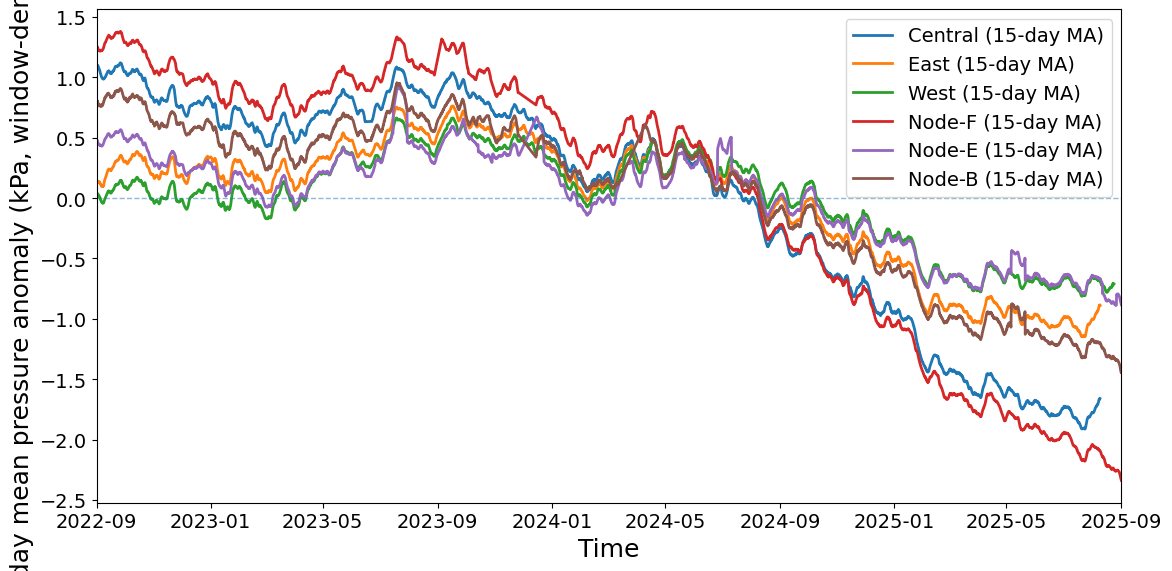

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

PSI_TO_KPA = 6.894757
COL_KPA = 'Corrected Pressure (kPa)'

start = pd.Timestamp('2022-09-01')
end   = pd.Timestamp('2025-09-01')

def to_ma15d(df, tcol, vcol, *, unit='kpa'):
    x = df[[tcol, vcol]].copy()
    x[tcol] = pd.to_datetime(x[tcol], errors='coerce')
    x = x.dropna(subset=[tcol]).sort_values(tcol)
    v = x[vcol].astype(float)
    if unit.lower() == 'psi':
        v = v * PSI_TO_KPA
    s = pd.Series(v.values, index=x[tcol])
    return s.rolling('15D', center=True, min_periods=1).mean()

def rebase_to_window(ma, start, end):
    w = ma.loc[start:end]
    return ma - w.mean()

# 15-day moving averages
ma_c  = to_ma15d(combined_df4, 'DateTime', COL_KPA, unit='kpa')
ma_e  = to_ma15d(combined_df2, 'DateTime', COL_KPA, unit='kpa')
ma_w  = to_ma15d(combined_df3, 'DateTime', COL_KPA, unit='kpa')
ma_cp = to_ma15d(cp,          'time',     'p',      unit='psi')  # cp.p is psi
ma_ep = to_ma15d(ep,          'time',     'p',      unit='psi')  # cp.p is psi
ma_wp = to_ma15d(wp,          'time',     'p',      unit='psi')  # cp.p is psi

# Re-baseline within the plotted window
ma_c  = rebase_to_window(ma_c,  start, end)
ma_e  = rebase_to_window(ma_e,  start, end)
ma_w  = rebase_to_window(ma_w,  start, end)
ma_cp = rebase_to_window(ma_cp, start, end)
ma_ep = rebase_to_window(ma_ep, start, end)
ma_wp = rebase_to_window(ma_wp, start, end)

# Plot only the window
plt.figure(figsize=(12, 6))
for s, name in [(ma_c, 'Central'), (ma_e, 'East'), (ma_w, 'West'), (ma_cp, 'Node-F'),(ma_ep, 'Node-E'),(ma_wp, 'Node-B')]:
    sw = s.loc[start:end]
    if not sw.empty:
        plt.plot(sw.index, sw.values, linewidth=2, label=f'{name} (15-day MA)')

plt.axhline(0, lw=1, ls='--', alpha=0.5)
plt.xlim(start, end)
plt.xlabel('Time')
plt.ylabel('15-day mean pressure anomaly (kPa, window-demeaned)')
plt.legend()
plt.tight_layout()
plt.show()


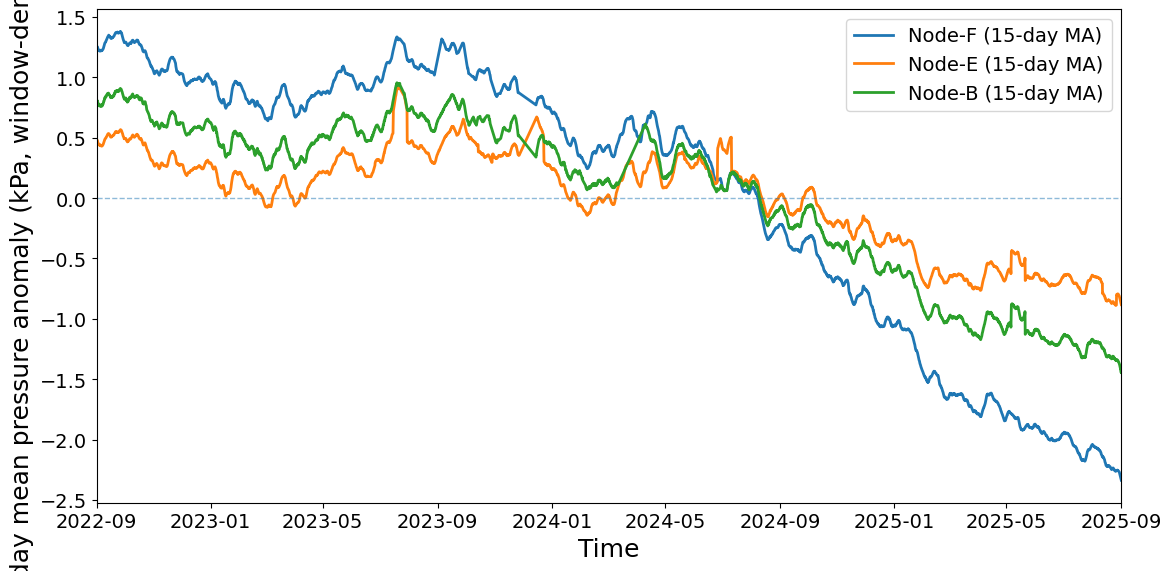

In [161]:
plt.figure(figsize=(12, 6))
for s, name in [(ma_cp, 'Node-F'),(ma_ep, 'Node-E'),(ma_wp, 'Node-B')]:
    sw = s.loc[start:end]
    if not sw.empty:
        plt.plot(sw.index, sw.values, linewidth=2, label=f'{name} (15-day MA)')

plt.axhline(0, lw=1, ls='--', alpha=0.5)
plt.xlim(start, end)
plt.xlabel('Time')
plt.ylabel('15-day mean pressure anomaly (kPa, window-demeaned)')
plt.legend()
plt.tight_layout()
plt.show()

In [166]:
import pandas as pd
import numpy as np

# --- inputs ---
date1 = pd.Timestamp("2022-09-15", tz="UTC")
date2 = pd.Timestamp("2025-08-25", tz="UTC")

# how wide to average around each date (days)
half_window_days = 3  # +/- 7 days

# conversion factor (cm depth change per kPa pressure change)
# (keep as a parameter since you may want to adjust/confirm)
CM_PER_KPA = 9.94

def window_mean(series, center, half_days=7):
    """Mean of series within [center-half_days, center+half_days]."""
    if series is None or len(series) == 0:
        return np.nan
    s = series.copy()
    # ensure datetime index
    if not isinstance(s.index, pd.DatetimeIndex):
        s.index = pd.to_datetime(s.index, utc=True, errors="coerce")
        s = s.dropna()
    # ensure tz-aware UTC
    if s.index.tz is None:
        s.index = s.index.tz_localize("UTC")
    else:
        s.index = s.index.tz_convert("UTC")

    t0 = center - pd.Timedelta(days=half_days)
    t1 = center + pd.Timedelta(days=half_days)
    w = s.loc[(s.index >= t0) & (s.index <= t1)]
    return float(w.mean()) if len(w) else np.nan

series_list = [
    (ma_cp, "Node-F"),
    (ma_ep, "Node-E"),
    (ma_wp, "Node-B"),
]

print(f"Depth change from {date1.date()} to {date2.date()} (using ±{half_window_days}d mean of 15-day MA)")
print("-"*80)

for s, name in series_list:
    p1 = window_mean(s, date1, half_window_days)  # kPa
    p2 = window_mean(s, date2, half_window_days)  # kPa
    dp = p2 - p1                                  # kPa

    dz_cm = dp * CM_PER_KPA                       # cm
    dz_m  = dz_cm / 100.0                         # m

    print(f"{name}:")
    print(f"  mean P @ {date1.date()} = {p1: .4f} kPa")
    print(f"  mean P @ {date2.date()} = {p2: .4f} kPa")
    print(f"  ΔP (end-start)          = {dp: .4f} kPa")
    print(f"  Δz = ΔP * {CM_PER_KPA}  = {dz_cm: .3f} cm  ({dz_m: .4f} m)")
    print()


Depth change from 2022-09-15 to 2025-08-25 (using ±3d mean of 15-day MA)
--------------------------------------------------------------------------------
Node-F:
  mean P @ 2022-09-15 =  1.3330 kPa
  mean P @ 2025-08-25 = -2.2501 kPa
  ΔP (end-start)          = -3.5831 kPa
  Δz = ΔP * 9.94  = -35.616 cm  (-0.3562 m)

Node-E:
  mean P @ 2022-09-15 =  0.5195 kPa
  mean P @ 2025-08-25 = -0.8575 kPa
  ΔP (end-start)          = -1.3770 kPa
  Δz = ΔP * 9.94  = -13.687 cm  (-0.1369 m)

Node-B:
  mean P @ 2022-09-15 =  0.8501 kPa
  mean P @ 2025-08-25 = -1.3299 kPa
  ΔP (end-start)          = -2.1800 kPa
  Δz = ΔP * 9.94  = -21.669 cm  (-0.2167 m)



In [19]:
ma_wp

time
2017-08-17 00:00:00    6.925209
2017-08-17 00:00:15    6.925205
2017-08-17 00:00:30    6.925202
2017-08-17 00:00:45    6.925197
2017-08-17 00:01:00    6.925191
                         ...   
2025-09-19 00:27:00   -1.270995
2025-09-19 00:27:15   -1.270983
2025-09-19 00:27:30   -1.270972
2025-09-19 00:27:45   -1.270961
2025-09-19 00:28:00   -1.270950
Length: 15919019, dtype: float64

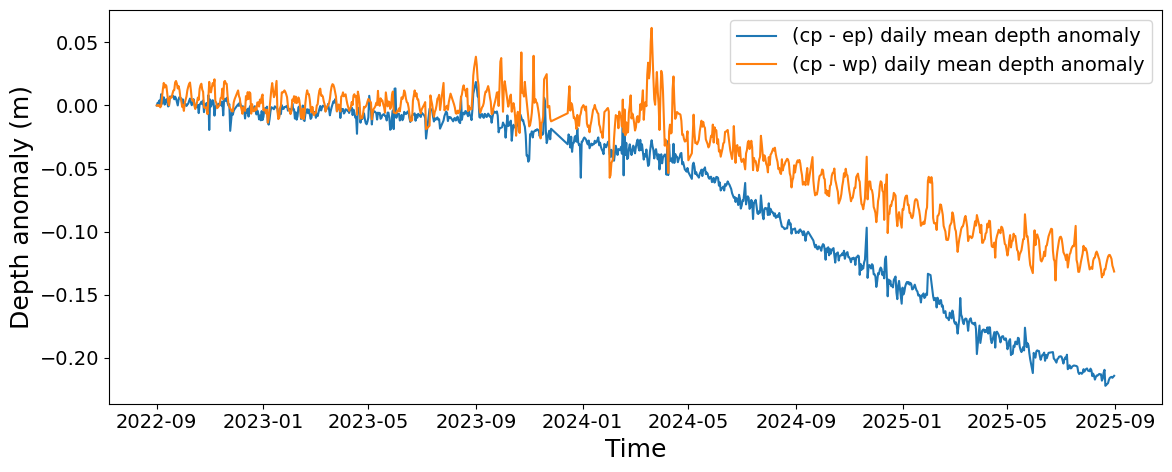

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

T0 = pd.Timestamp("2022-09-01", tz="UTC")
T1 = pd.Timestamp("2025-09-01", tz="UTC")  # exclusive

# --- outlier filter knobs (adjust if you want) ---
ROLL_DAYS = 31          # rolling window for "typical" behavior
MAD_THRESH = 2.0        # outlier if |x - roll_median| > MAD_THRESH * (1.4826*MAD)

def daily_mean_depth(df, t0, t1, name):
    d = df.loc[:, ["time", "depth"]].copy()
    d["time"]  = pd.to_datetime(d["time"], utc=True, errors="coerce")
    d["depth"] = pd.to_numeric(d["depth"], errors="coerce")
    d = d.dropna(subset=["time", "depth"])
    d = d[(d["time"] >= t0) & (d["time"] < t1)]
    s = d.set_index("time")["depth"].sort_index().resample("1D").mean()
    return s.rename(name)

def remove_outliers_rolling_mad(s, window_days=31, thresh=3.0):
    """
    Robustly flags outliers using deviation from rolling median scaled by rolling MAD.
    Outliers are set to NaN (so you can interpolate later).
    """
    # rolling median
    med = s.rolling(window=window_days, center=True, min_periods=max(5, window_days//5)).median()

    # rolling MAD: median(|x - median|)
    abs_dev = (s - med).abs()
    mad = abs_dev.rolling(window=window_days, center=True, min_periods=max(5, window_days//5)).median()

    # scale MAD to approx sigma for normal data
    sigma = 1.4826 * mad

    # avoid dividing by 0
    sigma = sigma.replace(0, np.nan)

    mask_out = abs_dev > (thresh * sigma)
    return s.mask(mask_out)

# 1) daily means
cp_day = daily_mean_depth(cp, T0, T1, "cp")
ep_day = daily_mean_depth(ep, T0, T1, "ep")
wp_day = daily_mean_depth(wp, T0, T1, "wp")

# 2) common daily grid
grid = pd.date_range(T0, T1, freq="1D", inclusive="left")
df = pd.concat([cp_day, ep_day, wp_day], axis=1).reindex(grid)

# 3) remove outliers (per column) BEFORE differencing
for c in ["cp", "ep", "wp"]:
    df[c] = remove_outliers_rolling_mad(df[c], window_days=ROLL_DAYS, thresh=MAD_THRESH)

# 4) fill gaps with time interpolation (inside only)
df = df.interpolate(method="time", limit_area="inside")

# 5) differencing + anomaly relative to first valid
cp_ep = df["cp"] - df["ep"]
cp_wp = df["cp"] - df["wp"]

cp_ep_anom = cp_ep - cp_ep.loc[cp_ep.first_valid_index()]
cp_wp_anom = cp_wp - cp_wp.loc[cp_wp.first_valid_index()]

# plot
plt.figure(figsize=(12, 5))
plt.plot(cp_ep_anom.index, cp_ep_anom.values, label="(cp - ep) daily mean depth anomaly")
plt.plot(cp_wp_anom.index, cp_wp_anom.values, label="(cp - wp) daily mean depth anomaly")
#plt.xlim(T1, T0)
plt.xlabel("Time")
plt.ylabel("Depth anomaly (m)")
plt.legend()
plt.tight_layout()
plt.show()


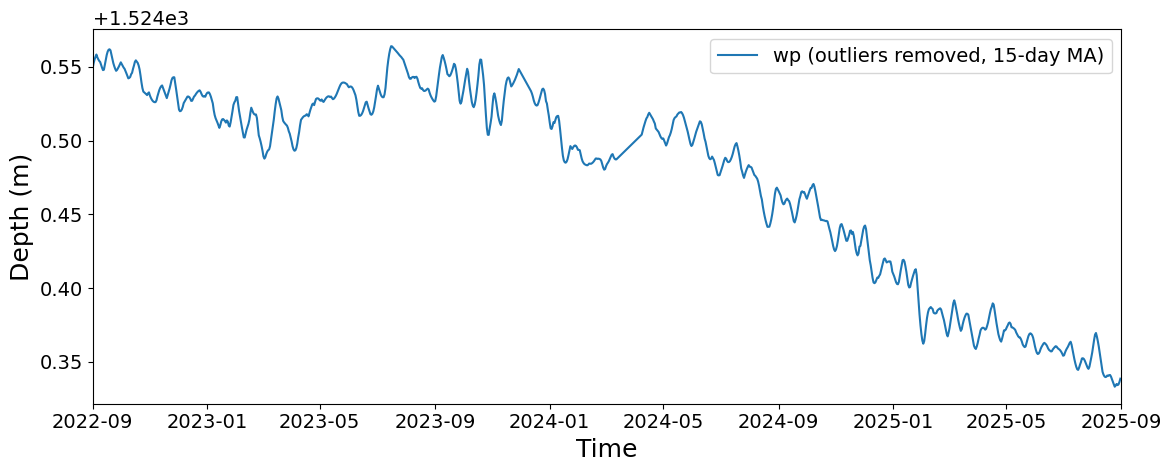

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

T0 = pd.Timestamp("2022-09-01", tz="UTC")
T1 = pd.Timestamp("2025-09-01", tz="UTC")  # exclusive

# --- outlier filter knobs ---
ROLL_DAYS = 15      # window used to define "typical" behavior
MAD_THRESH = 0.75    # outlier if |x - roll_median| > MAD_THRESH * (1.4826*MAD)

def daily_mean_depth(df, t0, t1, name):
    d = df.loc[:, ["time", "depth"]].copy()
    d["time"]  = pd.to_datetime(d["time"], utc=True, errors="coerce")
    d["depth"] = pd.to_numeric(d["depth"], errors="coerce")
    d = d.dropna(subset=["time", "depth"])
    d = d[(d["time"] >= t0) & (d["time"] < t1)]
    s = d.set_index("time")["depth"].sort_index().resample("1D").mean()
    return s.rename(name)

def remove_outliers_rolling_mad(s, window_days=31, thresh=3.0):
    med = s.rolling(window=window_days, center=True,
                    min_periods=max(5, window_days//5)).median()
    abs_dev = (s - med).abs()
    mad = abs_dev.rolling(window=window_days, center=True,
                          min_periods=max(5, window_days//5)).median()
    sigma = 1.4826 * mad
    sigma = sigma.replace(0, np.nan)
    out = abs_dev > (thresh * sigma)
    return s.mask(out)

# 1) Daily means
cp_day = daily_mean_depth(cp, T0, T1, "cp")
ep_day = daily_mean_depth(ep, T0, T1, "ep")
wp_day = daily_mean_depth(wp, T0, T1, "wp")

# 2) Remove outliers on the daily series (per-station), BEFORE any MA
cp_day = remove_outliers_rolling_mad(cp_day, window_days=ROLL_DAYS, thresh=MAD_THRESH)
ep_day = remove_outliers_rolling_mad(ep_day, window_days=ROLL_DAYS, thresh=MAD_THRESH)
wp_day = remove_outliers_rolling_mad(wp_day, window_days=ROLL_DAYS, thresh=MAD_THRESH)

# 3) Common daily grid + interpolate (inside only) to keep MA well-behaved
grid = pd.date_range(T0, T1, freq="1D", inclusive="left")
df = pd.concat([cp_day.rename("cp"), ep_day.rename("ep"), wp_day.rename("wp")], axis=1).reindex(grid)
df = df.interpolate(method="time", limit_area="inside")

# 4) 15-day moving average (centered)
df_ma15 = df.rolling(window=8, center=True, min_periods=3).mean()

# 5) Plot
plt.figure(figsize=(12, 5))
#plt.plot(df_ma15.index, df_ma15["cp"].values, label="cp (outliers removed, 15-day MA)")
#plt.plot(df_ma15.index, df_ma15["ep"].values, label="ep (outliers removed, 15-day MA)")
plt.plot(df_ma15.index, df_ma15["wp"].values, label="wp (outliers removed, 15-day MA)")
plt.xlim(T0, T1)
plt.xlabel("Time")
plt.ylabel("Depth (m)")
plt.legend()
plt.tight_layout()
plt.show()


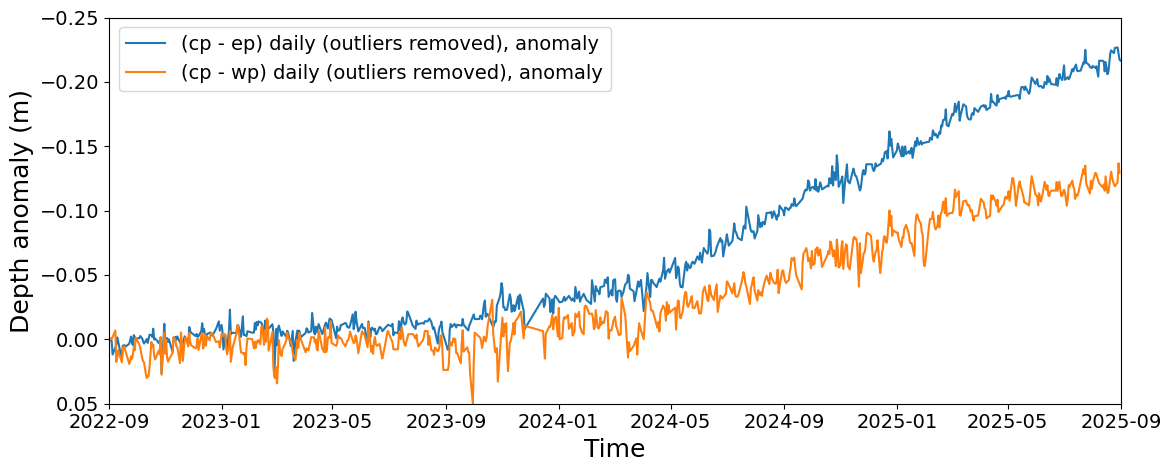

In [134]:
# ============================
# After step (2): outliers removed on cp_day/ep_day/wp_day
# do cp-ep and cp-wp on DAILY series (no moving average needed)
# ============================

# --- Put on common daily grid and interpolate (inside only) ---
grid = pd.date_range(T0, T1, freq="1D", inclusive="left")
df_day = (
    pd.concat([cp_day.rename("cp"), ep_day.rename("ep"), wp_day.rename("wp")], axis=1)
      .reindex(grid)
      .interpolate(method="time", limit_area="inside")
)

# --- Differences (daily) ---
cp_minus_ep_day = df_day["cp"] - df_day["ep"]
cp_minus_wp_day = df_day["cp"] - df_day["wp"]

# --- Anomaly relative to first valid (so gaps at start don't break it) ---
cp_minus_ep_anom = cp_minus_ep_day - cp_minus_ep_day.loc[cp_minus_ep_day.first_valid_index()]
cp_minus_wp_anom = cp_minus_wp_day - cp_minus_wp_day.loc[cp_minus_wp_day.first_valid_index()]

# --- Plot ---
plt.figure(figsize=(12, 5))
plt.plot(cp_minus_ep_anom.index, cp_minus_ep_anom.values, label="(cp - ep) daily (outliers removed), anomaly")
plt.plot(cp_minus_wp_anom.index, cp_minus_wp_anom.values, label="(cp - wp) daily (outliers removed), anomaly")
plt.xlim(T0, T1)
plt.ylim(0.05,-.25)
plt.xlabel("Time")
plt.ylabel("Depth anomaly (m)")
plt.legend()
plt.tight_layout()
plt.show()


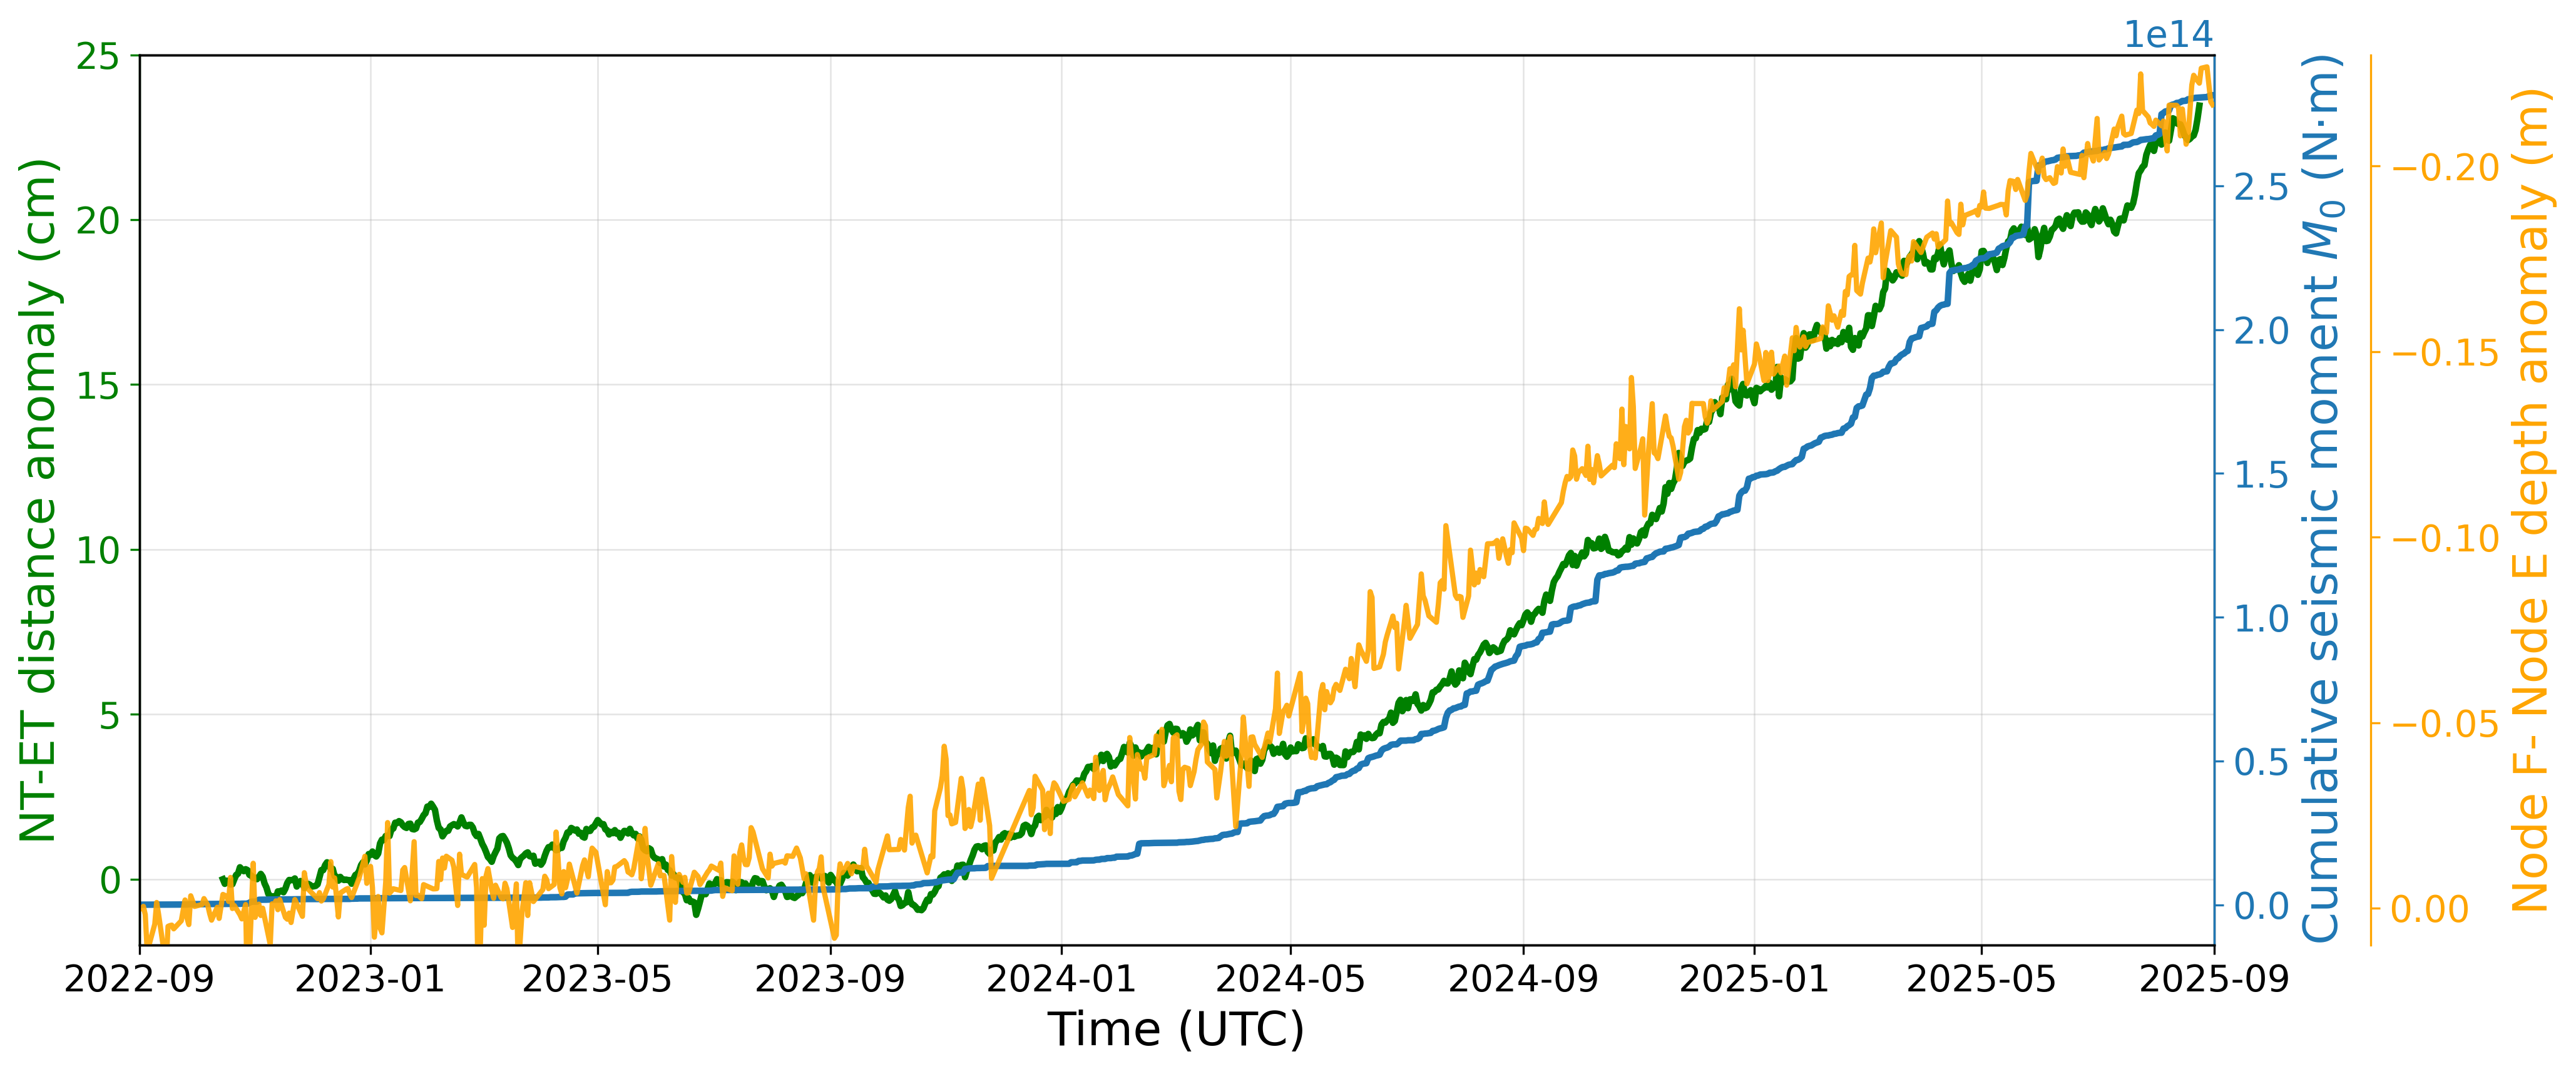

In [159]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 6), dpi=300)

# Axis 1 (left): baseline anomaly
c1 = "green"
l1, = ax1.plot(
    ce_anom.index, ce_anom.to_numpy(),
    linewidth=2.5, label="NT-ET (baseline anomaly)", color=c1
)
ax1.set_xlabel("Time (UTC)")
ax1.set_ylabel("NT-ET distance anomaly (cm)", color=c1)
ax1.tick_params(axis="y", colors=c1)
ax1.spines["left"].set_color(c1)
ax1.grid(True, linewidth=0.6, alpha=0.35)
ax1.set_xlim(TMIN, TMAX)
ax1.set_ylim(-2, 25)

# Axis 2 (right): cumulative moment
ax2 = ax1.twinx()
c2 = "tab:blue"
l2, = ax2.plot(
    all_days, east_cum_m0.to_numpy(),
    linewidth=2.5, label="East cumulative $M_0$", color=c2
)
ax2.set_ylabel("Cumulative seismic moment $M_0$ (N·m)", color=c2)
ax2.tick_params(axis="y", colors=c2)
ax2.spines["right"].set_color(c2)

# Axis 3 (extra right axis, offset outward): CP-EP anomaly
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))
ax3.spines["right"].set_visible(True)

c3 = "orange"
l3, = ax3.plot(
    cp_minus_ep_anom.index, cp_minus_ep_anom.to_numpy(),
    linewidth=2.0, label="F-E depth anomaly", color=c3, alpha=0.9
)
ax3.set_ylabel("Node F- Node E depth anomaly (m)", color=c3)
ax3.tick_params(axis="y", colors=c3)
ax3.spines["right"].set_color(c3)

# Set requested y-limits for the new axis (note order: lower, upper)
ax3.set_ylim(0.01, -0.23)

# Combined legend
lines = [l1, l2, l3]
labels = [ln.get_label() for ln in lines]
#ax1.legend(lines, labels, frameon=False, loc="upper left")

fig.tight_layout()
plt.show()


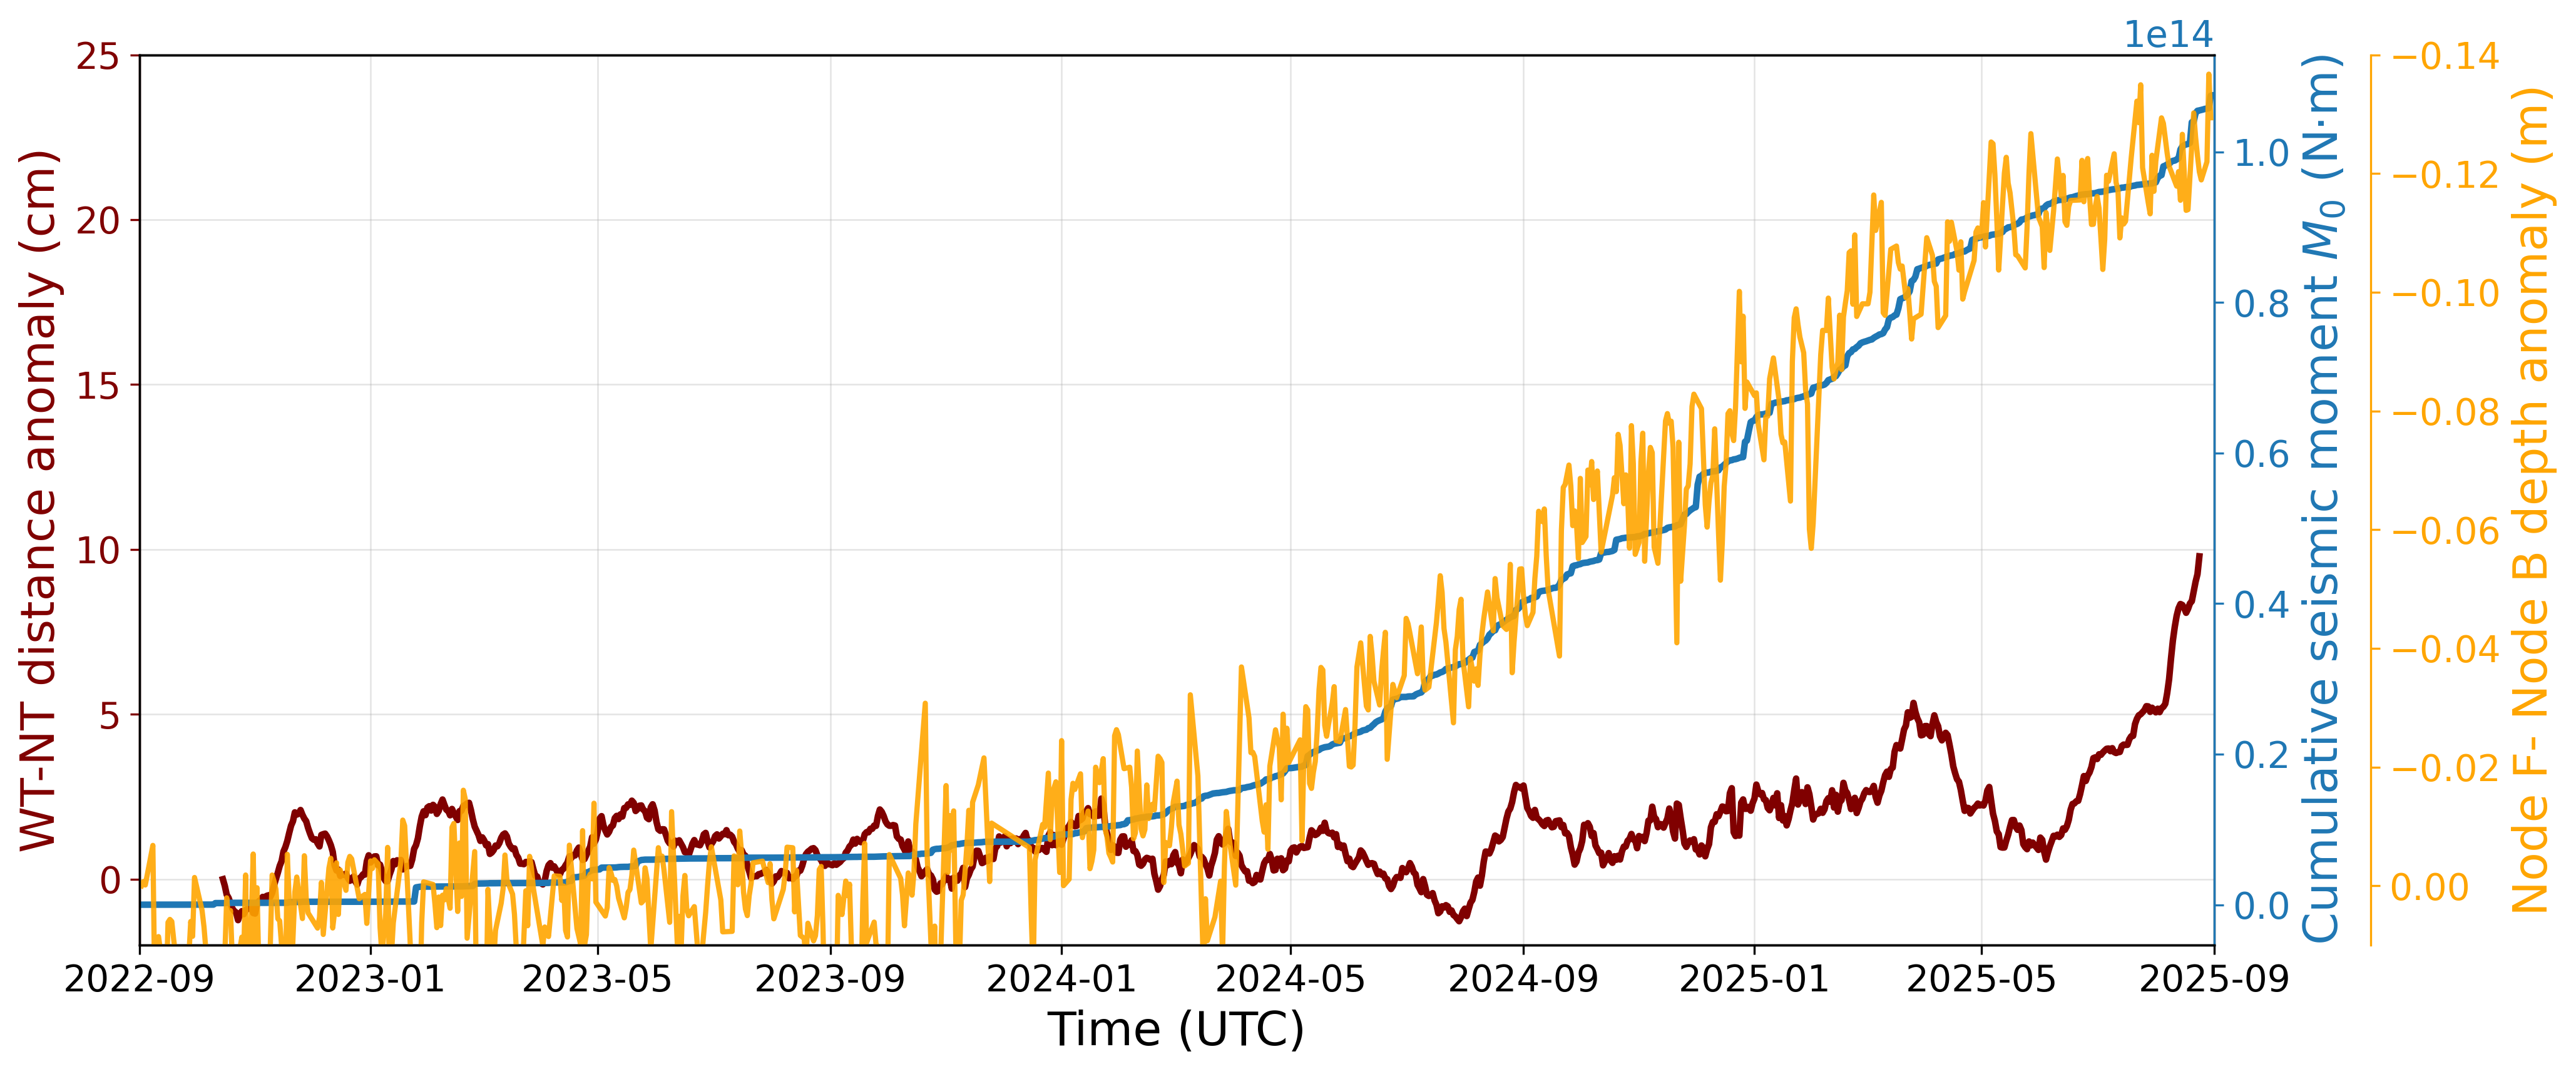

In [160]:
# --- Add this AFTER you have cp_minus_wp_anom computed (daily + outliers removed + differenced) ---
# (cp_minus_wp_anom should be a pandas Series indexed by UTC datetimes)

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

fig, ax1 = plt.subplots(figsize=(14, 6), dpi=300)

# Axis 1 (left): baseline anomaly (WE)
c1 = "maroon"
l1, = ax1.plot(
    we_anom.index, we_anom.to_numpy(),
    linewidth=2.5, label="WT-NT (baseline anomaly)", color=c1
)
ax1.set_xlabel("Time (UTC)")
ax1.set_ylabel("WT-NT distance anomaly (cm)", color=c1)
ax1.tick_params(axis="y", colors=c1)
ax1.spines["left"].set_color(c1)
ax1.grid(True, linewidth=0.6, alpha=0.35)
ax1.set_xlim(TMIN, TMAX)
ax1.set_ylim(-2, 25)

# Axis 2 (right): cumulative moment
ax2 = ax1.twinx()
c2 = "tab:blue"
l2, = ax2.plot(
    all_days, west_cum_m0.to_numpy(),
    linewidth=2.5, label="West cumulative $M_0$", color=c2
)
ax2.set_ylabel("Cumulative seismic moment $M_0$ (N·m)", color=c2)
ax2.tick_params(axis="y", colors=c2)
ax2.spines["right"].set_color(c2)

# Axis 3 (extra right axis, offset outward): CP-WP anomaly
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))
ax3.spines["right"].set_visible(True)

c3 = "orange"
l3, = ax3.plot(
    cp_minus_wp_anom.index, cp_minus_wp_anom.to_numpy(),
    linewidth=2.0, label="CP-WP depth anomaly", color=c3, alpha=0.9
)
ax3.set_ylabel("Node F- Node B depth anomaly (m)", color=c3)
ax3.tick_params(axis="y", colors=c3)
ax3.spines["right"].set_color(c3)

# If you want a fixed range like before, uncomment and edit:
ax3.set_ylim(0.01, -0.14)

# Combined legend
lines = [l1, l2, l3]
labels = [ln.get_label() for ln in lines]
#ax1.legend(lines, labels, frameon=False, loc="upper left")

fig.tight_layout()
plt.show()
